# Blinkit Data Analytics — Advanced Analysis
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


## 2. Data validation

### 2.1 Row and key counts per table

In [6]:
q('''
SELECT 'orders'    AS table_name, COUNT(*) AS rows, COUNT(DISTINCT order_id)    AS unique_keys FROM orders
UNION ALL SELECT 'order_items', COUNT(*), COUNT(DISTINCT order_id)    FROM items
UNION ALL SELECT 'customers',   COUNT(*), COUNT(DISTINCT customer_id) FROM customers_src
UNION ALL SELECT 'products',    COUNT(*), COUNT(DISTINCT product_id)  FROM products_src
UNION ALL SELECT 'delivery',    COUNT(*), COUNT(DISTINCT order_id)    FROM delivery_src
UNION ALL SELECT 'feedback',    COUNT(*), COUNT(DISTINCT feedback_id) FROM feedback
ORDER BY table_name ''')

,table_name,rows,unique_keys
0,customers,2500,2500
1,delivery,5000,5000
2,feedback,5000,5000
3,order_items,5000,5000
4,orders,5000,5000
5,products,268,268


### 2.2 Duplicate primary keys

In [7]:
q('''
WITH d AS (
  SELECT 'orders.order_id'       AS key_name, order_id::VARCHAR    AS key_value, COUNT(*) AS n FROM orders    GROUP BY 2
  UNION ALL SELECT 'customers.customer_id', customer_id::VARCHAR, COUNT(*) FROM customers_src GROUP BY 2
  UNION ALL SELECT 'products.product_id',   product_id::VARCHAR,  COUNT(*) FROM products_src  GROUP BY 2
  UNION ALL SELECT 'feedback.feedback_id',  feedback_id::VARCHAR, COUNT(*) FROM feedback      GROUP BY 2
)
SELECT key_name, COUNT(*) FILTER (WHERE n > 1) AS duplicate_keys, COUNT(*) AS distinct_keys
FROM d GROUP BY key_name ORDER BY key_name ''')

,key_name,duplicate_keys,distinct_keys
0,customers.customer_id,0,2500
1,feedback.feedback_id,0,5000
2,orders.order_id,0,5000
3,products.product_id,0,268


### 2.3 Missing values by column

In [8]:
frames = {'orders':book['Orders_Raw_Archive'],'order_items':book['Order_Line_Items'],
          'customers':book['Customers'],'products':book['Products'],
          'delivery':book['Delivery_Performance'],'feedback':book['Customer_Feedback']}
rows = []
for name, df in frames.items():
    for col in df.columns:
        miss = int(df[col].isna().sum()) + int((df[col].astype(str).str.strip() == '').sum())
        if miss:
            rows.append({'table':name,'column':col,'missing':miss,'missing_pct':pct(miss,len(df))})
pd.DataFrame(rows).sort_values('missing', ascending=False).reset_index(drop=True)

,table,column,missing,missing_pct
0,orders,reasons_if_delayed,1902,38.04
1,delivery,reasons_if_delayed,1902,38.04


### 2.4 Referential integrity

In [9]:
q('''
SELECT 'items.order_id -> orders'        AS relation, COUNT(*) AS orphan_rows FROM items i    LEFT JOIN orders o ON o.order_id = i.order_id WHERE o.order_id IS NULL
UNION ALL SELECT 'items.product_id -> products', COUNT(*) FROM items i     LEFT JOIN products_src p  ON p.product_id  = i.product_id  WHERE p.product_id  IS NULL
UNION ALL SELECT 'orders.customer_id -> customers', COUNT(*) FROM orders o LEFT JOIN customers_src c ON c.customer_id = o.customer_id WHERE c.customer_id IS NULL
UNION ALL SELECT 'delivery.order_id -> orders', COUNT(*) FROM delivery_src d LEFT JOIN orders o ON o.order_id = d.order_id WHERE o.order_id IS NULL
UNION ALL SELECT 'feedback.order_id -> orders', COUNT(*) FROM feedback f   LEFT JOIN orders o ON o.order_id = f.order_id WHERE o.order_id IS NULL
UNION ALL SELECT 'orders.area -> geo', COUNT(*) FROM orders o LEFT JOIN geo g ON g.area = o.area WHERE g.area IS NULL ''')

,relation,orphan_rows
0,items.order_id -> orders,0
1,items.product_id -> products,0
2,orders.customer_id -> customers,0
3,delivery.order_id -> orders,0
4,feedback.order_id -> orders,0
5,orders.area -> geo,0


### 2.5 Business rule checks

In [10]:
q('''
SELECT 'quantity <= 0'                      AS rule, COUNT(*) AS failing_rows FROM items WHERE quantity <= 0
UNION ALL SELECT 'unit price > MRP',              COUNT(*) FROM items  WHERE price > mrp
UNION ALL SELECT 'line total <> qty * price',     COUNT(*) FROM items  WHERE abs(line_total - quantity * price) > 0.01
UNION ALL SELECT 'delivery before order time',    COUNT(*) FROM orders WHERE actual_ts < order_ts
UNION ALL SELECT 'promised before order time',    COUNT(*) FROM orders WHERE promised_ts < order_ts
UNION ALL SELECT 'rating outside 1-5',            COUNT(*) FROM feedback WHERE rating < 1 OR rating > 5
UNION ALL SELECT 'shelf life <= 0',               COUNT(*) FROM products_src WHERE shelf_life_days <= 0
UNION ALL SELECT 'min stock > max stock',         COUNT(*) FROM products_src WHERE min_stock_level > max_stock_level
UNION ALL SELECT 'registration after first order',COUNT(*) FROM (
      SELECT customer_id, MIN(order_date) AS first_order, MIN(registration_date) AS reg FROM orders GROUP BY 1)
      WHERE reg > first_order ''')

,rule,failing_rows
0,quantity <= 0,0
1,unit price > MRP,0
2,line total <> qty * price,0
3,delivery before order time,0
4,promised before order time,0
5,rating outside 1-5,0
6,shelf life <= 0,0
7,min stock > max stock,0
8,registration after first order,1438


### 2.6 Order total in orders table vs sum of line items

In [11]:
q('''
WITH cmp AS (
  SELECT o.order_id, o.order_total, i.line_total,
         round(o.order_total - i.line_total, 2) AS diff
  FROM orders o JOIN items i ON i.order_id = o.order_id
)
SELECT COUNT(*) AS orders_compared,
       COUNT(*) FILTER (WHERE abs(diff) > 0.01) AS mismatched_orders,
       round(AVG(diff), 2)  AS avg_difference,
       round(SUM(order_total), 2) AS total_in_orders_table,
       round(SUM(line_total), 2)  AS total_in_items_table
FROM cmp ''')

,orders_compared,mismatched_orders,avg_difference,total_in_orders_table,total_in_items_table
0,5000,4999,"1,207.38","11,009,308.50","4,972,415.43"


### 2.7 Items per order

In [12]:
q('''
SELECT items_per_order, COUNT(*) AS orders FROM (
  SELECT order_id, COUNT(*) AS items_per_order FROM items GROUP BY 1)
GROUP BY 1 ORDER BY 1 ''')

,items_per_order,orders
0,1,5000


### 2.8 Customer segment label vs actual ordering behaviour

In [13]:
q('''
SELECT c.customer_segment                              AS label,
       COUNT(DISTINCT c.customer_id)                   AS customers_labelled,
       COUNT(DISTINCT o.customer_id)                   AS customers_who_ordered,
       COUNT(o.order_id)                               AS orders,
       round(SUM(o.order_total), 0)                    AS revenue,
       round(COUNT(o.order_id) * 1.0 / NULLIF(COUNT(DISTINCT o.customer_id), 0), 2) AS orders_per_buyer
FROM customers_src c
LEFT JOIN orders o ON o.customer_id = c.customer_id
GROUP BY 1 ORDER BY revenue DESC ''')

,label,customers_labelled,customers_who_ordered,orders,revenue,orders_per_buyer
0,Regular,639,574,1320,"2,890,149.00",2.30
1,New,628,530,1222,"2,795,854.00",2.31
2,Premium,633,550,1268,"2,731,330.00",2.31
3,Inactive,600,518,1190,"2,591,976.00",2.30


### 2.9 Date coverage

In [14]:
q('''
SELECT MIN(order_date) AS first_order, MAX(order_date) AS last_order,
       date_diff('day', MIN(order_date), MAX(order_date)) AS days_covered,
       COUNT(DISTINCT order_date)  AS days_with_orders,
       COUNT(DISTINCT date_trunc('month', order_date)) AS months_covered
FROM orders ''')

,first_order,last_order,days_covered,days_with_orders,months_covered
0,2023-03-16,2024-11-04,599,600,21


## 3. Sales performance

### 3.1 Headline figures

In [15]:
q('''
SELECT COUNT(DISTINCT order_id)              AS orders,
       COUNT(DISTINCT customer_id)           AS buying_customers,
       SUM(quantity)                         AS units,
       round(SUM(revenue), 2)                AS revenue,
       round(SUM(revenue) / COUNT(DISTINCT order_id), 2) AS avg_order_value,
       round(SUM(margin_value), 2)           AS gross_margin,
       round(100 * SUM(margin_value) / SUM(revenue), 2)  AS margin_pct,
       round(AVG(rating), 2)                 AS avg_rating
FROM f_sales ''')

,orders,buying_customers,units,revenue,avg_order_value,gross_margin,margin_pct,avg_rating
0,5000,2172,"10,034.00","4,972,415.43",994.48,"1,361,602.88",27.38,3.34


### 3.2 Monthly revenue with month-over-month growth

In [16]:
q('''
WITH m AS (
  SELECT order_month, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS revenue, SUM(quantity) AS units
  FROM f_sales GROUP BY 1)
SELECT strftime(order_month, '%Y-%m')                 AS month,
       orders, round(revenue, 0) AS revenue, units,
       round(revenue / orders, 0)                      AS aov,
       round(revenue - LAG(revenue) OVER (ORDER BY order_month), 0) AS revenue_change,
       round(100 * (revenue - LAG(revenue) OVER (ORDER BY order_month))
             / NULLIF(LAG(revenue) OVER (ORDER BY order_month), 0), 2) AS mom_growth_pct,
       round(100 * (orders - LAG(orders) OVER (ORDER BY order_month))
             / NULLIF(LAG(orders) OVER (ORDER BY order_month), 0), 2)  AS mom_order_growth_pct
FROM m ORDER BY order_month ''')

,month,orders,revenue,units,aov,revenue_change,mom_growth_pct,mom_order_growth_pct
0,2023-03,120,"110,990.00",227.00,925.00,NaN,NaN,NaN
1,2023-04,238,"249,383.00",483.00,"1,048.00","138,393.00",124.69,98.33
2,2023-05,276,"269,445.00",560.00,976.00,"20,063.00",8.04,15.97
3,2023-06,232,"233,673.00",457.00,"1,007.00","-35,772.00",-13.28,-15.94
4,2023-07,244,"237,061.00",470.00,972.00,"3,388.00",1.45,5.17
5,2023-08,285,"303,512.00",580.00,"1,065.00","66,451.00",28.03,16.80
6,2023-09,262,"277,585.00",537.00,"1,059.00","-25,927.00",-8.54,-8.07
7,2023-10,254,"263,860.00",531.00,"1,039.00","-13,726.00",-4.94,-3.05
8,2023-11,265,"261,475.00",549.00,987.00,"-2,385.00",-0.90,4.33
9,2023-12,268,"253,628.00",524.00,946.00,"-7,846.00",-3.00,1.13


### 3.3 Running revenue and share of total

In [17]:
q('''
WITH m AS (SELECT order_month, SUM(revenue) AS revenue FROM f_sales GROUP BY 1)
SELECT strftime(order_month, '%Y-%m') AS month,
       round(revenue, 0)              AS revenue,
       round(SUM(revenue) OVER (ORDER BY order_month ROWS UNBOUNDED PRECEDING), 0) AS running_revenue,
       round(100 * SUM(revenue) OVER (ORDER BY order_month ROWS UNBOUNDED PRECEDING)
             / SUM(revenue) OVER (), 2) AS running_share_pct,
       round(AVG(revenue) OVER (ORDER BY order_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 0) AS moving_avg_3m
FROM m ORDER BY order_month ''')

,month,revenue,running_revenue,running_share_pct,moving_avg_3m
0,2023-03,"110,990.00","110,990.00",2.23,"110,990.00"
1,2023-04,"249,383.00","360,372.00",7.25,"180,186.00"
2,2023-05,"269,445.00","629,817.00",12.67,"209,939.00"
3,2023-06,"233,673.00","863,490.00",17.37,"250,834.00"
4,2023-07,"237,061.00","1,100,551.00",22.13,"246,726.00"
5,2023-08,"303,512.00","1,404,063.00",28.24,"258,082.00"
6,2023-09,"277,585.00","1,681,649.00",33.82,"272,719.00"
7,2023-10,"263,860.00","1,945,509.00",39.13,"281,652.00"
8,2023-11,"261,475.00","2,206,983.00",44.38,"267,640.00"
9,2023-12,"253,628.00","2,460,612.00",49.49,"259,654.00"


### 3.4 Revenue by category with contribution and rank

In [18]:
q('''
SELECT category,
       COUNT(DISTINCT order_id)                       AS orders,
       SUM(quantity)                                  AS units,
       round(SUM(revenue), 0)                         AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       RANK() OVER (ORDER BY SUM(revenue) DESC)       AS revenue_rank,
       round(SUM(revenue) / COUNT(DISTINCT order_id), 0) AS aov,
       round(SUM(margin_value), 0)                    AS margin_value,
       RANK() OVER (ORDER BY SUM(margin_value) DESC)  AS margin_rank
FROM f_sales GROUP BY 1 ORDER BY revenue DESC ''')

,category,orders,units,revenue,revenue_share_pct,revenue_rank,aov,margin_value,margin_rank
0,Dairy & Breakfast,566,"1,114.00","639,222.00",12.86,1,"1,129.00","127,844.00",5
1,Pharmacy,481,973.00,"592,369.00",11.91,2,"1,232.00","118,474.00",7
2,Fruits & Vegetables,492,966.00,"559,053.00",11.24,3,"1,136.00","139,763.00",2
3,Pet Care,501,"1,003.00","539,889.00",10.86,4,"1,078.00","188,961.00",1
4,Household Care,509,"1,078.00","444,244.00",8.93,5,873.00,"111,061.00",9
5,Personal Care,454,887.00,"394,895.00",7.94,6,870.00,"138,213.00",3
6,Snacks & Munchies,483,963.00,"394,649.00",7.94,7,817.00,"138,127.00",4
7,Cold Drinks & Juices,375,758.00,"392,718.00",7.90,8,"1,047.00","117,815.00",8
8,Grocery & Staples,449,895.00,"359,938.00",7.24,9,802.00,"53,991.00",11
9,Baby Care,334,655.00,"348,227.00",7.00,10,"1,043.00","104,468.00",10


### 3.5 Top 15 products by revenue

In [19]:
q('''
SELECT DENSE_RANK() OVER (ORDER BY SUM(revenue) DESC) AS rnk,
       product_name, category,
       COUNT(DISTINCT order_id) AS orders, SUM(quantity) AS units,
       round(SUM(revenue), 0)   AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS share_pct
FROM f_sales GROUP BY product_name, category ORDER BY revenue DESC LIMIT 15 ''')

,rnk,product_name,category,orders,units,revenue,share_pct
0,1,Vitamins,Pharmacy,183,380.00,"260,822.00",5.25
1,2,Pet Treats,Pet Care,233,473.00,"252,007.00",5.07
2,3,Cough Syrup,Pharmacy,190,373.00,"203,570.00",4.09
3,4,Toilet Cleaner,Household Care,205,430.00,"199,837.00",4.02
4,5,Bread,Dairy & Breakfast,135,270.00,"184,851.00",3.72
5,6,Dish Soap,Household Care,184,397.00,"184,441.00",3.71
6,7,Cat Food,Pet Care,152,307.00,"166,596.00",3.35
7,8,Baby Wipes,Baby Care,176,328.00,"158,768.00",3.19
8,9,Onions,Fruits & Vegetables,112,222.00,"138,858.00",2.79
9,10,Baby Food,Baby Care,115,236.00,"137,443.00",2.76


### 3.6 Bottom 15 product codes by revenue

In [20]:
q('''
SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
       COUNT(DISTINCT order_id) AS orders, SUM(quantity) AS units, round(SUM(revenue), 0) AS revenue
FROM f_sales GROUP BY product_id ORDER BY revenue ASC LIMIT 15 ''')

,product_id,product_name,category,orders,units,revenue
0,118820,Iced Tea,Cold Drinks & Juices,14,30.00,370.00
1,654297,Potatoes,Fruits & Vegetables,17,36.00,477.00
2,962054,Orange Juice,Cold Drinks & Juices,16,30.00,506.00
3,652118,Frozen Biryani,Instant & Frozen Food,16,34.00,749.00
4,767398,Dish Soap,Household Care,14,34.00,753.00
5,300159,Cola,Cold Drinks & Juices,12,21.00,931.00
6,709916,Detergent,Household Care,15,34.00,"1,148.00"
7,133542,Detergent,Household Care,9,17.00,"1,164.00"
8,473647,Toothpaste,Personal Care,15,30.00,"1,291.00"
9,968887,Dish Soap,Household Care,19,39.00,"1,587.00"


### 3.7 Pareto check on product codes

In [21]:
q('''
WITH p AS (SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1),
r AS (SELECT product_id, revenue,
             ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
             SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) AS cum_rev,
             SUM(revenue) OVER () AS total_rev,
             COUNT(*) OVER () AS total_products FROM p)
SELECT share_of_products || '% of product codes' AS product_group,
       MIN(rn) AS codes_needed,
       round(100 * MAX(cum_rev) / MAX(total_rev), 2) AS revenue_share_pct
FROM (SELECT *, CASE WHEN rn <= 0.1 * total_products THEN 10
                     WHEN rn <= 0.2 * total_products THEN 20
                     WHEN rn <= 0.5 * total_products THEN 50
                     ELSE 100 END AS share_of_products FROM r)
GROUP BY share_of_products ORDER BY share_of_products ''')

,product_group,codes_needed,revenue_share_pct
0,10% of product codes,1,23.11
1,20% of product codes,27,41.49
2,50% of product codes,54,78.68
3,100% of product codes,135,100.00


### 3.8 Number of product codes needed for 50, 70, 80 and 90 percent of revenue

In [22]:
q('''
WITH p AS (SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1),
r AS (SELECT product_id, ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
             100 * SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) / SUM(revenue) OVER () AS cum_pct
      FROM p)
SELECT t AS revenue_target_pct,
       MIN(rn) AS product_codes_needed,
       round(100.0 * MIN(rn) / (SELECT COUNT(*) FROM p), 1) AS pct_of_catalogue
FROM r, (SELECT unnest([50, 70, 80, 90]) AS t)
WHERE cum_pct >= t GROUP BY t ORDER BY t ''')

,revenue_target_pct,product_codes_needed,pct_of_catalogue
0,50,68,25.40
1,70,110,41.00
2,80,139,51.90
3,90,178,66.40


### 3.9 Order value distribution

In [23]:
q('''
SELECT CASE WHEN revenue < 250 THEN 'a. under 250'
            WHEN revenue < 500 THEN 'b. 250-500'
            WHEN revenue < 750 THEN 'c. 500-750'
            WHEN revenue < 1000 THEN 'd. 750-1000'
            WHEN revenue < 1500 THEN 'e. 1000-1500'
            WHEN revenue < 2000 THEN 'f. 1500-2000'
            WHEN revenue < 3000 THEN 'g. 2000-3000'
            ELSE 'h. 3000 and above' END AS order_value_band,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,order_value_band,orders,order_share_pct,revenue,revenue_share_pct
0,a. under 250,792,15.84,"106,401.00",2.14
1,b. 250-500,867,17.34,"322,303.00",6.48
2,c. 500-750,749,14.98,"473,019.00",9.51
3,d. 750-1000,799,15.98,"711,143.00",14.30
4,e. 1000-1500,544,10.88,"677,288.00",13.62
5,f. 1500-2000,626,12.52,"1,102,958.00",22.18
6,g. 2000-3000,623,12.46,"1,579,304.00",31.76


### 3.10 Order value deciles

In [24]:
q('''
WITH d AS (SELECT order_id, revenue, NTILE(10) OVER (ORDER BY revenue) AS decile FROM f_sales)
SELECT decile, COUNT(*) AS orders,
       round(MIN(revenue), 0) AS min_value, round(MAX(revenue), 0) AS max_value,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM d GROUP BY decile ORDER BY decile ''')

,decile,orders,min_value,max_value,revenue,revenue_share_pct
0,1,500,12.00,163.00,"46,503.00",0.94
1,2,500,163.00,310.00,"117,887.00",2.37
2,3,500,310.00,447.00,"188,500.00",3.79
3,4,500,448.00,632.00,"269,185.00",5.41
4,5,500,632.00,795.00,"351,637.00",7.07
5,6,500,795.00,950.00,"438,121.00",8.81
6,7,500,950.00,"1,263.00","534,378.00",10.75
7,8,500,"1,263.00","1,729.00","748,203.00",15.05
8,9,500,"1,729.00","2,215.00","959,011.00",19.29
9,10,500,"2,215.00","2,988.00","1,318,989.00",26.53


### 3.11 Category revenue by month

In [25]:
q('''
SELECT category,
       round(SUM(revenue) FILTER (WHERE order_month < DATE '2023-10-01'), 0) AS q_2023_early,
       round(SUM(revenue) FILTER (WHERE order_month BETWEEN DATE '2023-10-01' AND DATE '2024-03-01'), 0) AS oct23_mar24,
       round(SUM(revenue) FILTER (WHERE order_month BETWEEN DATE '2024-04-01' AND DATE '2024-11-01'), 0) AS apr24_nov24,
       round(SUM(revenue), 0) AS total_revenue
FROM f_sales GROUP BY category ORDER BY total_revenue DESC ''')

,category,q_2023_early,oct23_mar24,apr24_nov24,total_revenue
0,Dairy & Breakfast,"205,031.00","204,060.00","230,131.00","639,222.00"
1,Pharmacy,"199,007.00","190,253.00","203,109.00","592,369.00"
2,Fruits & Vegetables,"219,171.00","163,251.00","176,630.00","559,053.00"
3,Pet Care,"173,385.00","168,735.00","197,769.00","539,889.00"
4,Household Care,"133,087.00","139,307.00","171,850.00","444,244.00"
5,Personal Care,"141,628.00","118,357.00","134,910.00","394,895.00"
6,Snacks & Munchies,"119,614.00","136,790.00","138,245.00","394,649.00"
7,Cold Drinks & Juices,"155,100.00","106,299.00","131,319.00","392,718.00"
8,Grocery & Staples,"111,870.00","123,621.00","124,447.00","359,938.00"
9,Baby Care,"112,618.00","116,221.00","119,388.00","348,227.00"


### 3.12 Daily revenue outliers

In [26]:
q('''
WITH d AS (SELECT order_date, SUM(revenue) AS revenue, COUNT(*) AS orders FROM f_sales GROUP BY 1),
s AS (SELECT AVG(revenue) AS mu, stddev_samp(revenue) AS sd FROM d)
SELECT order_date, orders, round(revenue, 0) AS revenue,
       round((revenue - mu) / sd, 2) AS z_score
FROM d, s WHERE abs((revenue - mu) / sd) > 2
ORDER BY abs((revenue - mu) / sd) DESC LIMIT 12 ''')

,order_date,orders,revenue,z_score
0,2024-08-27,15,"20,528.00",3.29
1,2023-10-09,14,"19,637.00",3.05
2,2024-10-26,11,"18,552.00",2.76
3,2023-09-09,16,"18,443.00",2.73
4,2023-09-05,13,"18,385.00",2.71
5,2024-01-10,14,"18,234.00",2.67
6,2024-10-15,12,"17,996.00",2.61
7,2023-04-09,11,"17,934.00",2.59
8,2023-08-21,10,"17,905.00",2.59
9,2024-06-21,15,"17,820.00",2.56


## 4. Customer analysis

### 4.1 Customer base summary

In [27]:
q('''
WITH c AS (
  SELECT customer_id, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS spend,
         MIN(order_date) AS first_order, MAX(order_date) AS last_order
  FROM f_sales GROUP BY 1)
SELECT (SELECT COUNT(*) FROM customers_src)               AS registered_customers,
       COUNT(*)                                           AS customers_who_ordered,
       COUNT(*) FILTER (WHERE orders = 1)                 AS one_order_only,
       COUNT(*) FILTER (WHERE orders >= 2)                AS repeat_customers,
       round(100.0 * COUNT(*) FILTER (WHERE orders >= 2) / COUNT(*), 2) AS repeat_rate_pct,
       round(AVG(orders), 2)                              AS avg_orders_per_customer,
       round(AVG(spend), 2)                               AS avg_spend_per_customer,
       round(SUM(spend) FILTER (WHERE orders >= 2) * 100.0 / SUM(spend), 2) AS repeat_revenue_share_pct
FROM c ''')

,registered_customers,customers_who_ordered,one_order_only,repeat_customers,repeat_rate_pct,avg_orders_per_customer,avg_spend_per_customer,repeat_revenue_share_pct
0,2500,2172,680,1492,68.69,2.30,"2,289.33",86.74


### 4.2 Distribution of orders per customer

In [28]:
q('''
WITH c AS (SELECT customer_id, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS spend FROM f_sales GROUP BY 1)
SELECT orders AS orders_placed, COUNT(*) AS customers,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_share_pct,
       round(SUM(spend), 0) AS revenue,
       round(100 * SUM(spend) / SUM(SUM(spend)) OVER (), 2) AS revenue_share_pct
FROM c GROUP BY orders ORDER BY orders ''')

,orders_placed,customers,customer_share_pct,revenue,revenue_share_pct
0,1,680,31.31,"659,315.00",13.26
1,2,686,31.58,"1,377,284.00",27.70
2,3,451,20.76,"1,342,203.00",26.99
3,4,234,10.77,"946,597.00",19.04
4,5,82,3.78,"400,895.00",8.06
5,6,28,1.29,"167,163.00",3.36
6,7,8,0.37,"54,394.00",1.09
7,8,2,0.09,"14,449.00",0.29
8,9,1,0.05,"10,116.00",0.20


### 4.3 Top 15 customers by spend

In [29]:
q('''
SELECT RANK() OVER (ORDER BY SUM(revenue) DESC) AS rnk,
       any_value(customer_name) AS customer, customer_id,
       any_value(state) AS state, any_value(customer_segment) AS label,
       COUNT(DISTINCT order_id) AS orders, round(SUM(revenue), 0) AS spend,
       round(AVG(revenue), 0) AS avg_order, MAX(order_date) AS last_order
FROM f_sales GROUP BY customer_id ORDER BY spend DESC LIMIT 15 ''')

,rnk,customer,customer_id,state,label,orders,spend,avg_order,last_order
0,1,Odika Kannan,25128143,Telangana,Premium,7,"10,533.00","1,505.00",2024-01-27
1,2,Nidhi Sha,77869660,Gujarat,Premium,9,"10,116.00","1,124.00",2024-09-08
2,3,Dev Bal,12272282,Rajasthan,Regular,5,"9,925.00","1,985.00",2024-10-07
3,4,Lipika Kumer,4597433,Andhra Pradesh,Inactive,6,"9,554.00","1,592.00",2024-08-26
4,5,Leena Deol,33331259,Bihar,Inactive,4,"9,404.00","2,351.00",2024-06-11
5,6,Ayaan Rege,14472401,Kerala,Regular,4,"9,276.00","2,319.00",2024-06-24
6,7,Zinal Dhawan,85561151,Uttar Pradesh,Regular,4,"9,269.00","2,317.00",2024-01-10
7,8,Jacob Lad,22800586,Karnataka,New,4,"9,237.00","2,309.00",2024-03-06
8,9,Wishi Varughese,34668988,Maharashtra,Inactive,4,"9,161.00","2,290.00",2024-09-27
9,10,Anvi Savant,13760839,Assam,Premium,5,"9,114.00","1,823.00",2024-06-10


### 4.4 Customer revenue concentration by decile

In [30]:
q('''
WITH c AS (SELECT customer_id, SUM(revenue) AS spend FROM f_sales GROUP BY 1),
d AS (SELECT customer_id, spend, NTILE(10) OVER (ORDER BY spend DESC) AS decile FROM c)
SELECT decile, COUNT(*) AS customers, round(SUM(spend), 0) AS revenue,
       round(100 * SUM(spend) / SUM(SUM(spend)) OVER (), 2) AS revenue_share_pct,
       round(100 * SUM(SUM(spend)) OVER (ORDER BY decile ROWS UNBOUNDED PRECEDING) / SUM(SUM(spend)) OVER (), 2) AS cumulative_share_pct
FROM d GROUP BY decile ORDER BY decile ''')

,decile,customers,revenue,revenue_share_pct,cumulative_share_pct
0,1,218,"1,293,729.00",26.02,26.02
1,2,218,"875,134.00",17.60,43.62
2,3,217,"698,776.00",14.05,57.67
3,4,217,"575,848.00",11.58,69.25
4,5,217,"473,719.00",9.53,78.78
5,6,217,"384,796.00",7.74,86.52
6,7,217,"291,648.00",5.87,92.38
7,8,217,"200,292.00",4.03,96.41
8,9,217,"129,302.00",2.60,99.01
9,10,217,"49,170.00",0.99,100.00


### 4.5 New versus repeat revenue by month

In [31]:
q('''
WITH first_order AS (SELECT customer_id, MIN(order_date) AS first_date FROM f_sales GROUP BY 1),
tagged AS (
  SELECT s.order_month, s.revenue,
         CASE WHEN s.order_date = f.first_date THEN 'new' ELSE 'repeat' END AS customer_type
  FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id)
SELECT strftime(order_month, '%Y-%m') AS month,
       round(SUM(revenue) FILTER (WHERE customer_type = 'new'), 0)    AS new_customer_revenue,
       round(SUM(revenue) FILTER (WHERE customer_type = 'repeat'), 0) AS repeat_customer_revenue,
       round(100 * SUM(revenue) FILTER (WHERE customer_type = 'repeat') / SUM(revenue), 2) AS repeat_share_pct
FROM tagged GROUP BY order_month ORDER BY order_month ''')

,month,new_customer_revenue,repeat_customer_revenue,repeat_share_pct
0,2023-03,"109,083.00","1,907.00",1.72
1,2023-04,"224,414.00","24,969.00",10.01
2,2023-05,"231,032.00","38,413.00",14.26
3,2023-06,"179,469.00","54,204.00",23.20
4,2023-07,"166,695.00","70,366.00",29.68
5,2023-08,"180,161.00","123,351.00",40.64
6,2023-09,"140,222.00","137,364.00",49.49
7,2023-10,"139,884.00","123,976.00",46.99
8,2023-11,"116,777.00","144,698.00",55.34
9,2023-12,"96,124.00","157,504.00",62.10


### 4.6 Gap between consecutive orders

In [32]:
q('''
WITH seq AS (
  SELECT customer_id, order_date,
         ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS order_no,
         LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS prev_date
  FROM (SELECT DISTINCT customer_id, order_date FROM f_sales)),
gaps AS (SELECT order_no, date_diff('day', prev_date, order_date) AS gap_days FROM seq WHERE prev_date IS NOT NULL)
SELECT order_no AS order_number, COUNT(*) AS transitions,
       round(AVG(gap_days), 1) AS avg_gap_days,
       round(median(gap_days), 1) AS median_gap_days,
       MIN(gap_days) AS min_gap, MAX(gap_days) AS max_gap
FROM gaps WHERE order_no <= 6 GROUP BY order_no ORDER BY order_no ''')

,order_number,transitions,avg_gap_days,median_gap_days,min_gap,max_gap
0,2,1490,164.50,135.00,1,545
1,3,804,131.80,99.50,1,532
2,4,351,113.20,86.00,1,357
3,5,121,91.20,82.00,2,273
4,6,39,99.20,88.00,1,311


### 4.7 Monthly cohort retention

In [33]:
q('''
WITH first_order AS (SELECT customer_id, date_trunc('month', MIN(order_date)) AS cohort FROM f_sales GROUP BY 1),
activity AS (
  SELECT f.cohort, date_diff('month', f.cohort, s.order_month) AS month_index, s.customer_id
  FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id),
sized AS (SELECT cohort, COUNT(DISTINCT customer_id) AS cohort_size FROM activity WHERE month_index = 0 GROUP BY 1)
SELECT strftime(a.cohort, '%Y-%m') AS cohort_month, s.cohort_size,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 1) / s.cohort_size, 1) AS m1_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 2) / s.cohort_size, 1) AS m2_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 3) / s.cohort_size, 1) AS m3_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index BETWEEN 4 AND 6) / s.cohort_size, 1) AS m4_m6_pct
FROM activity a JOIN sized s ON s.cohort = a.cohort
GROUP BY a.cohort, s.cohort_size ORDER BY a.cohort ''')

,cohort_month,cohort_size,m1_pct,m2_pct,m3_pct,m4_m6_pct
0,2023-03,117,11.10,8.50,3.40,26.50
1,2023-04,217,8.80,11.50,10.10,30.40
2,2023-05,233,9.40,6.00,11.60,29.60
3,2023-06,175,7.40,9.70,10.30,28.00
4,2023-07,171,9.90,7.60,11.70,25.10
5,2023-08,166,7.80,8.40,4.80,22.90
6,2023-09,137,10.20,10.20,8.80,24.10
7,2023-10,135,11.90,14.10,7.40,25.90
8,2023-11,117,10.30,12.00,6.80,29.90
9,2023-12,105,11.40,8.60,6.70,21.90


### 4.8 Recency, frequency and monetary table

In [34]:
rfm = q('''
WITH base AS (SELECT MAX(order_date) AS as_of FROM f_sales)
SELECT s.customer_id,
       date_diff('day', MAX(s.order_date), (SELECT as_of FROM base)) AS recency_days,
       COUNT(DISTINCT s.order_id)  AS frequency,
       round(SUM(s.revenue), 2)    AS monetary,
       round(AVG(s.revenue), 2)    AS avg_order_value,
       date_diff('day', MIN(s.order_date), MAX(s.order_date)) AS tenure_days,
       any_value(s.zone) AS zone, any_value(s.customer_segment) AS label
FROM f_sales s GROUP BY s.customer_id ''')
print(rfm.shape)
rfm.describe()[['recency_days','frequency','monetary','avg_order_value','tenure_days']]

(2172, 8)


,recency_days,frequency,monetary,avg_order_value,tenure_days
count,"2,172.00","2,172.00","2,172.00","2,172.00","2,172.00"
mean,206.39,2.30,"2,289.33",990.22,187.16
std,156.39,1.25,"1,713.52",577.64,178.28
min,0.00,1.00,12.32,12.32,0.00
25%,73.00,1.00,919.79,569.83,0.00
50%,170.00,2.00,"1,959.98",899.68,156.00
75%,315.25,3.00,"3,225.06","1,331.26",340.00
max,599.00,9.00,"10,533.39","2,929.65",590.00


### 4.9 Customers who never ordered

In [35]:
q('''
SELECT c.customer_segment AS label, COUNT(*) AS never_ordered
FROM customers_src c LEFT JOIN orders o ON o.customer_id = c.customer_id
WHERE o.order_id IS NULL GROUP BY 1 ORDER BY never_ordered DESC ''')

,label,never_ordered
0,New,98
1,Premium,83
2,Inactive,82
3,Regular,65


## 5. Activation funnel

### 5.1 Funnel from registration to third order

In [36]:
q('''
WITH c AS (
  SELECT cs.customer_id, COUNT(DISTINCT o.order_id) AS orders
  FROM customers_src cs LEFT JOIN orders o ON o.customer_id = cs.customer_id GROUP BY 1)
SELECT 'Registered'       AS stage, COUNT(*) AS customers, 100.0 AS pct_of_registered FROM c
UNION ALL SELECT 'Placed 1st order', COUNT(*) FILTER (WHERE orders >= 1), round(100.0 * COUNT(*) FILTER (WHERE orders >= 1) / COUNT(*), 2) FROM c
UNION ALL SELECT 'Placed 2nd order', COUNT(*) FILTER (WHERE orders >= 2), round(100.0 * COUNT(*) FILTER (WHERE orders >= 2) / COUNT(*), 2) FROM c
UNION ALL SELECT 'Placed 3rd order', COUNT(*) FILTER (WHERE orders >= 3), round(100.0 * COUNT(*) FILTER (WHERE orders >= 3) / COUNT(*), 2) FROM c
UNION ALL SELECT 'Placed 4th order or more', COUNT(*) FILTER (WHERE orders >= 4), round(100.0 * COUNT(*) FILTER (WHERE orders >= 4) / COUNT(*), 2) FROM c ''')

,stage,customers,pct_of_registered
0,Registered,2500,100.00
1,Placed 1st order,2172,86.88
2,Placed 2nd order,1492,59.68
3,Placed 3rd order,806,32.24
4,Placed 4th order or more,355,14.20


### 5.2 Drop-off between stages

In [37]:
funnel = q('''
WITH c AS (SELECT cs.customer_id, COUNT(DISTINCT o.order_id) AS orders
           FROM customers_src cs LEFT JOIN orders o ON o.customer_id = cs.customer_id GROUP BY 1)
SELECT COUNT(*) AS registered,
       COUNT(*) FILTER (WHERE orders >= 1) AS first_order,
       COUNT(*) FILTER (WHERE orders >= 2) AS second_order,
       COUNT(*) FILTER (WHERE orders >= 3) AS third_order FROM c ''').iloc[0]
steps = [('Registered to 1st order', funnel.registered, funnel.first_order),
         ('1st to 2nd order',        funnel.first_order, funnel.second_order),
         ('2nd to 3rd order',        funnel.second_order, funnel.third_order)]
pd.DataFrame([{'step':s,'from':int(a),'to':int(b),'lost':int(a-b),'drop_off_pct':pct(a-b,a)} for s,a,b in steps])

,step,from,to,lost,drop_off_pct
0,Registered to 1st order,2500,2172,328,13.12
1,1st to 2nd order,2172,1492,680,31.31
2,2nd to 3rd order,1492,806,686,45.98


### 5.3 Days from registration to first order

In [38]:
q('''
WITH f AS (
  SELECT customer_id, MIN(order_date) AS first_order, MIN(registration_date) AS reg FROM orders GROUP BY 1)
SELECT CASE WHEN date_diff('day', reg, first_order) < 0 THEN 'a. order before registration (data issue)'
            WHEN date_diff('day', reg, first_order) <= 7   THEN 'b. within 7 days'
            WHEN date_diff('day', reg, first_order) <= 30  THEN 'c. 8 to 30 days'
            WHEN date_diff('day', reg, first_order) <= 90  THEN 'd. 31 to 90 days'
            ELSE 'e. more than 90 days' END AS activation_speed,
       COUNT(*) AS customers,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct
FROM f GROUP BY 1 ORDER BY 1 ''')

,activation_speed,customers,share_pct
0,a. order before registration (data issue),1438,66.21
1,b. within 7 days,27,1.24
2,c. 8 to 30 days,78,3.59
3,d. 31 to 90 days,192,8.84
4,e. more than 90 days,437,20.12


### 5.4 Gap to second order in bands

In [39]:
q('''
WITH seq AS (
  SELECT customer_id, order_date,
         ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS order_no,
         LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS prev_date
  FROM (SELECT DISTINCT customer_id, order_date FROM f_sales)),
g AS (SELECT date_diff('day', prev_date, order_date) AS gap FROM seq WHERE order_no = 2)
SELECT CASE WHEN gap <= 30 THEN 'a. 0-30 days' WHEN gap <= 60 THEN 'b. 31-60 days'
            WHEN gap <= 90 THEN 'c. 61-90 days' WHEN gap <= 180 THEN 'd. 91-180 days'
            WHEN gap <= 365 THEN 'e. 181-365 days' ELSE 'f. over 365 days' END AS gap_band,
       COUNT(*) AS customers,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct
FROM g GROUP BY 1 ORDER BY 1 ''')

,gap_band,customers,share_pct
0,a. 0-30 days,197,13.22
1,b. 31-60 days,188,12.62
2,c. 61-90 days,156,10.47
3,d. 91-180 days,367,24.63
4,e. 181-365 days,438,29.40
5,f. over 365 days,144,9.66


### 5.5 Repeat purchase curve (Kaplan-Meier estimate)

In [40]:
first_second = q('''
WITH seq AS (
  SELECT customer_id, order_date,
         ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS order_no
  FROM (SELECT DISTINCT customer_id, order_date FROM f_sales)),
f AS (SELECT customer_id, MIN(order_date) FILTER (WHERE order_no = 1) AS first_date,
             MIN(order_date) FILTER (WHERE order_no = 2) AS second_date
      FROM seq GROUP BY customer_id)
SELECT customer_id, first_date, second_date,
       (SELECT MAX(order_date) FROM f_sales) AS study_end FROM f ''')

first_second['duration'] = np.where(first_second.second_date.notna(),
    (pd.to_datetime(first_second.second_date) - pd.to_datetime(first_second.first_date)).dt.days,
    (pd.to_datetime(first_second.study_end) - pd.to_datetime(first_second.first_date)).dt.days)
first_second['event'] = first_second.second_date.notna().astype(int)

times = np.sort(first_second.loc[first_second.event == 1, 'duration'].unique())
n = len(first_second); surv = 1.0; km = []
for t in times:
    at_risk = (first_second.duration >= t).sum()
    events  = ((first_second.duration == t) & (first_second.event == 1)).sum()
    surv *= (1 - events / at_risk)
    km.append({'days': int(t), 'at_risk': int(at_risk), 'repeat_orders': int(events),
               'not_returned_prob': round(surv, 4), 'returned_prob': round(1 - surv, 4)})
km_df = pd.DataFrame(km)
km_df[km_df.days.isin([7, 14, 30, 60, 90, 120, 180, 270, 365])]

,days,at_risk,repeat_orders,not_returned_prob,returned_prob
6,7,2122,4,0.98,0.02
13,14,2063,6,0.95,0.05
29,30,1953,6,0.91,0.09
59,60,1726,5,0.82,0.18
89,90,1539,7,0.74,0.26
118,120,1356,7,0.67,0.33
175,180,1056,1,0.56,0.44
258,270,692,3,0.41,0.59
341,365,410,4,0.30,0.70


## 6. Product, category and margin

### 6.1 Category rank by revenue against rank by margin

In [41]:
q('''
WITH c AS (
  SELECT category, SUM(revenue) AS revenue, SUM(margin_value) AS margin_value,
         AVG(margin_percentage) AS margin_pct FROM f_sales GROUP BY 1)
SELECT category, round(revenue, 0) AS revenue, round(margin_pct, 1) AS margin_pct,
       round(margin_value, 0) AS margin_value,
       RANK() OVER (ORDER BY revenue DESC)      AS revenue_rank,
       RANK() OVER (ORDER BY margin_value DESC) AS margin_rank,
       RANK() OVER (ORDER BY revenue DESC) - RANK() OVER (ORDER BY margin_value DESC) AS rank_shift,
       round(100 * margin_value / SUM(margin_value) OVER (), 2) AS margin_share_pct
FROM c ORDER BY margin_value DESC ''')

,category,revenue,margin_pct,margin_value,revenue_rank,margin_rank,rank_shift,margin_share_pct
0,Pet Care,"539,889.00",35.00,"188,961.00",4,1,3,13.88
1,Fruits & Vegetables,"559,053.00",25.00,"139,763.00",3,2,1,10.26
2,Personal Care,"394,895.00",35.00,"138,213.00",6,3,3,10.15
3,Snacks & Munchies,"394,649.00",35.00,"138,127.00",7,4,3,10.14
4,Dairy & Breakfast,"639,222.00",20.00,"127,844.00",1,5,-4,9.39
5,Instant & Frozen Food,"307,213.00",40.00,"122,885.00",11,6,5,9.03
6,Pharmacy,"592,369.00",20.00,"118,474.00",2,7,-5,8.70
7,Cold Drinks & Juices,"392,718.00",30.00,"117,815.00",8,8,0,8.65
8,Household Care,"444,244.00",25.00,"111,061.00",5,9,-4,8.16
9,Baby Care,"348,227.00",30.00,"104,468.00",10,10,0,7.67


### 6.2 Top 3 products inside each category

In [42]:
q('''
WITH p AS (
  SELECT category, product_name, SUM(revenue) AS revenue, SUM(quantity) AS units
  FROM f_sales GROUP BY 1, 2),
r AS (SELECT *, ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC) AS rn,
             100 * revenue / SUM(revenue) OVER (PARTITION BY category) AS share_in_category
      FROM p)
SELECT category, rn AS rank_in_category, product_name, round(revenue, 0) AS revenue,
       units, round(share_in_category, 1) AS share_in_category_pct
FROM r WHERE rn <= 3 ORDER BY category, rn ''')

,category,rank_in_category,product_name,revenue,units,share_in_category_pct
0,Baby Care,1,Baby Wipes,"158,768.00",328.00,45.60
1,Baby Care,2,Baby Food,"137,443.00",236.00,39.50
2,Baby Care,3,Diapers,"52,016.00",91.00,14.90
3,Cold Drinks & Juices,1,Cola,"132,367.00",230.00,33.70
4,Cold Drinks & Juices,2,Orange Juice,"106,444.00",222.00,27.10
5,Cold Drinks & Juices,3,Iced Tea,"71,171.00",118.00,18.10
6,Dairy & Breakfast,1,Bread,"184,851.00",270.00,28.90
7,Dairy & Breakfast,2,Eggs,"137,397.00",246.00,21.50
8,Dairy & Breakfast,3,Butter,"106,843.00",148.00,16.70
9,Fruits & Vegetables,1,Onions,"138,858.00",222.00,24.80


### 6.3 Product codes per product name

In [43]:
q('''
SELECT product_name, any_value(category) AS category,
       COUNT(DISTINCT product_id) AS product_codes,
       COUNT(DISTINCT order_id)   AS orders,
       round(SUM(revenue), 0)     AS revenue,
       round(SUM(revenue) / COUNT(DISTINCT product_id), 0) AS revenue_per_code
FROM f_sales GROUP BY product_name HAVING COUNT(DISTINCT product_id) > 1
ORDER BY product_codes DESC, revenue DESC LIMIT 15 ''')

,product_name,category,product_codes,orders,revenue,revenue_per_code
0,Pet Treats,Pet Care,12,233,"252,007.00","21,001.00"
1,Vitamins,Pharmacy,10,183,"260,822.00","26,082.00"
2,Toilet Cleaner,Household Care,10,205,"199,837.00","19,984.00"
3,Dish Soap,Household Care,10,184,"184,441.00","18,444.00"
4,Lotion,Personal Care,10,188,"136,400.00","13,640.00"
5,Cough Syrup,Pharmacy,9,190,"203,570.00","22,619.00"
6,Baby Wipes,Baby Care,8,176,"158,768.00","19,846.00"
7,Pulses,Grocery & Staples,8,137,"94,641.00","11,830.00"
8,Bread,Dairy & Breakfast,7,135,"184,851.00","26,407.00"
9,Cat Food,Pet Care,7,152,"166,596.00","23,799.00"


### 6.4 ABC classification of product codes

In [44]:
abc = q('''
WITH p AS (SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
                  SUM(revenue) AS revenue, SUM(quantity) AS units FROM f_sales GROUP BY product_id),
r AS (SELECT *, 100 * SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) / SUM(revenue) OVER () AS cum_pct
      FROM p)
SELECT *, CASE WHEN cum_pct <= 80 THEN 'A' WHEN cum_pct <= 95 THEN 'B' ELSE 'C' END AS abc_class FROM r ''')
abc.groupby('abc_class').agg(products=('product_id','count'), revenue=('revenue','sum'),
                             units=('units','sum')).assign(
    revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2),
    product_share_pct=lambda d: (100*d.products/d.products.sum()).round(2)).reset_index()

,abc_class,products,revenue,units,revenue_share_pct,product_share_pct
0,A,138,"3,974,367.98","5,499.00",79.93,51.49
1,B,67,"742,673.10","2,339.00",14.94,25.00
2,C,63,"255,374.35","2,196.00",5.14,23.51


### 6.5 XYZ classification on demand variability

In [45]:
monthly = q('''
SELECT product_id, order_month, SUM(quantity) AS units FROM f_sales GROUP BY 1, 2 ''')
piv = monthly.pivot_table(index='product_id', columns='order_month', values='units', aggfunc='sum').fillna(0)
cv = (piv.std(axis=1) / piv.mean(axis=1).replace(0, np.nan)).rename('cv')
xyz = cv.to_frame().assign(xyz_class=lambda d: pd.cut(d.cv, [-0.01, 0.5, 1.0, np.inf], labels=['X','Y','Z']))
abc_xyz = abc.set_index('product_id')[['product_name','category','revenue','abc_class']].join(xyz)
matrix = pd.crosstab(abc_xyz.abc_class, abc_xyz.xyz_class)
matrix.loc['Total'] = matrix.sum(); matrix['Total'] = matrix.sum(axis=1)
matrix

xyz_class,Y,Z,Total
abc_class,,,
A,40,98,138
B,8,59,67
C,14,49,63
Total,62,206,268


### 6.6 Revenue and risk profile of each ABC-XYZ group

In [46]:
abc_xyz.assign(group=abc_xyz.abc_class.astype(str) + abc_xyz.xyz_class.astype(str)) \
    .groupby('group').agg(products=('revenue','size'), revenue=('revenue','sum'), avg_cv=('cv','mean')) \
    .assign(revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2),
            avg_cv=lambda d: d.avg_cv.round(2)).sort_values('revenue', ascending=False).reset_index()

,group,products,revenue,avg_cv,revenue_share_pct
0,AZ,98,"2,724,770.71",1.23,54.80
1,AY,40,"1,249,597.27",0.91,25.13
2,BZ,59,"642,590.96",1.27,12.92
3,CZ,49,"200,438.19",1.23,4.03
4,BY,8,"100,082.14",0.93,2.01
5,CY,14,"54,936.16",0.94,1.10


### 6.7 Price band performance

In [47]:
q('''
SELECT CASE WHEN price < 50 THEN 'a. under 50' WHEN price < 100 THEN 'b. 50-100'
            WHEN price < 250 THEN 'c. 100-250' WHEN price < 500 THEN 'd. 250-500'
            ELSE 'e. 500 and above' END AS price_band,
       COUNT(DISTINCT product_id) AS product_codes, SUM(quantity) AS units,
       round(SUM(revenue), 0) AS revenue, round(AVG(price), 0) AS avg_price,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,price_band,product_codes,units,revenue,avg_price,revenue_share_pct
0,a. under 50,14,500.00,"16,986.00",34.00,0.34
1,b. 50-100,16,598.00,"49,686.00",83.00,1.00
2,c. 100-250,44,"1,631.00","291,163.00",178.00,5.86
3,d. 250-500,73,"2,641.00","979,722.00",371.00,19.70
4,e. 500 and above,121,"4,664.00","3,634,859.00",777.00,73.10


## 7. SKU rationalisation

### 7.1 Revenue contribution of the weakest product codes

In [48]:
q('''
WITH p AS (SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
                  SUM(revenue) AS revenue, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY product_id),
r AS (SELECT *, NTILE(4) OVER (ORDER BY revenue) AS quartile FROM p)
SELECT quartile, COUNT(*) AS product_codes, round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       round(AVG(orders), 1) AS avg_orders_per_code
FROM r GROUP BY quartile ORDER BY quartile ''')

,quartile,product_codes,revenue,revenue_share_pct,avg_orders_per_code
0,1,67,"286,298.00",5.76,17.90
1,2,67,"773,769.00",15.56,17.40
2,3,67,"1,442,179.00",29.00,18.20
3,4,67,"2,470,169.00",49.68,21.10


### 7.2 Merge and review candidates

In [49]:
cand = q('''
WITH p AS (SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
                  SUM(revenue) AS revenue, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY product_id),
n AS (SELECT product_name, COUNT(*) AS codes_for_name, SUM(revenue) AS name_revenue FROM p GROUP BY product_name)
SELECT p.product_id, p.product_name, p.category, p.orders, round(p.revenue, 0) AS revenue,
       n.codes_for_name, round(100 * p.revenue / n.name_revenue, 1) AS share_within_name,
       CASE WHEN n.codes_for_name > 1 AND 100 * p.revenue / n.name_revenue < 8 THEN 'merge into main code'
            WHEN p.orders <= 3 THEN 'review for removal'
            ELSE 'keep' END AS recommendation
FROM p JOIN n ON n.product_name = p.product_name ''')
cand.groupby('recommendation').agg(product_codes=('product_id','count'), orders=('orders','sum'),
    revenue=('revenue','sum')).assign(revenue_share_pct=lambda d: (100*d.revenue/cand.revenue.sum()).round(2)).reset_index()

,recommendation,product_codes,orders,revenue,revenue_share_pct
0,keep,194,3690,"4,532,097.00",91.14
1,merge into main code,74,1310,"440,320.00",8.86


### 7.3 Codes proposed for merging

In [50]:
cand[cand.recommendation == 'merge into main code'] \
    .sort_values('revenue').head(12)[['product_id','product_name','category','orders','revenue','codes_for_name','share_within_name']]

,product_id,product_name,category,orders,revenue,codes_for_name,share_within_name
171,118820,Iced Tea,Cold Drinks & Juices,14,370.00,3,0.50
42,654297,Potatoes,Fruits & Vegetables,17,477.00,7,0.50
145,962054,Orange Juice,Cold Drinks & Juices,16,506.00,7,0.50
243,652118,Frozen Biryani,Instant & Frozen Food,16,749.00,7,0.70
111,767398,Dish Soap,Household Care,14,753.00,10,0.40
156,300159,Cola,Cold Drinks & Juices,12,931.00,7,0.70
12,709916,Detergent,Household Care,15,"1,148.00",7,1.90
265,133542,Detergent,Household Care,9,"1,164.00",7,1.90
112,473647,Toothpaste,Personal Care,15,"1,291.00",5,1.30
99,968887,Dish Soap,Household Care,19,"1,587.00",10,0.90


## 8. Delivery performance

### 8.1 Delivery status against actual minutes

In [51]:
q('''
SELECT delivery_status,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct,
       round(AVG(delay_min), 2)  AS avg_minutes_vs_promise,
       MIN(delay_min) AS min_minutes, MAX(delay_min) AS max_minutes,
       COUNT(*) FILTER (WHERE delay_min > 0) AS arrived_after_promise
FROM f_sales GROUP BY 1 ORDER BY orders DESC ''')

,delivery_status,orders,share_pct,avg_minutes_vs_promise,min_minutes,max_minutes,arrived_after_promise
0,On Time,3470,69.40,0.01,-5,5,1568
1,Slightly Delayed,1037,20.74,10.52,6,15,1037
2,Significantly Delayed,493,9.86,22.84,16,30,493


### 8.2 Promise accuracy summary

In [52]:
q('''
SELECT COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_by_status_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min <= 0) / COUNT(*), 2)        AS on_or_before_promise_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 0) / COUNT(*), 2)         AS after_promise_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 10) / COUNT(*), 2)        AS more_than_10_min_late_pct,
       round(AVG(delay_min) FILTER (WHERE delay_min > 0), 2)                      AS avg_delay_when_late,
       round(quantile_cont(delay_min, 0.5), 1)  AS p50_minutes,
       round(quantile_cont(delay_min, 0.9), 1)  AS p90_minutes,
       round(quantile_cont(delay_min, 0.95), 1) AS p95_minutes
FROM f_sales ''')

,orders,on_time_by_status_pct,on_or_before_promise_pct,after_promise_pct,more_than_10_min_late_pct,avg_delay_when_late,p50_minutes,p90_minutes,p95_minutes
0,5000,69.40,38.04,61.96,20.14,8.69,2.00,15.00,23.00


### 8.3 Distribution of minutes against promise

In [53]:
q('''
SELECT CASE WHEN delay_min <= -5 THEN 'a. 5 or more minutes early'
            WHEN delay_min < 0   THEN 'b. 1 to 4 minutes early'
            WHEN delay_min = 0   THEN 'c. exactly on promise'
            WHEN delay_min <= 5  THEN 'd. 1 to 5 minutes late'
            WHEN delay_min <= 10 THEN 'e. 6 to 10 minutes late'
            WHEN delay_min <= 20 THEN 'f. 11 to 20 minutes late'
            ELSE 'g. more than 20 minutes late' END AS band,
       COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct,
       round(SUM(revenue), 0) AS revenue
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,band,orders,share_pct,revenue
0,a. 5 or more minutes early,316,6.32,"325,553.00"
1,b. 1 to 4 minutes early,1247,24.94,"1,262,082.00"
2,c. exactly on promise,339,6.78,"327,300.00"
3,d. 1 to 5 minutes late,1568,31.36,"1,536,949.00"
4,e. 6 to 10 minutes late,523,10.46,"497,734.00"
5,f. 11 to 20 minutes late,674,13.48,"688,053.00"
6,g. more than 20 minutes late,333,6.66,"334,745.00"


### 8.4 On-time rate by state

In [54]:
q('''
SELECT state, zone, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 10) / COUNT(*), 2)        AS very_late_pct,
       round(AVG(delay_min), 2) AS avg_minutes_vs_promise,
       round(AVG(distance_km), 2) AS avg_distance_km,
       RANK() OVER (ORDER BY 1.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) DESC) AS rank_on_time
FROM f_sales GROUP BY state, zone HAVING COUNT(*) >= 30 ORDER BY on_time_pct DESC ''')

,state,zone,orders,on_time_pct,very_late_pct,avg_minutes_vs_promise,avg_distance_km,rank_on_time
0,Kerala,South,106,76.42,16.04,3.86,2.69,1
1,Rajasthan,North,178,73.60,18.54,4.00,2.74,2
2,Odisha,East,83,73.49,14.46,3.89,2.68,3
3,Gujarat,West,204,72.06,20.10,4.80,2.65,4
4,Punjab,North,114,71.93,21.05,3.87,2.64,5
5,Jammu and Kashmir,North,32,71.88,18.75,4.59,2.66,6
6,Madhya Pradesh,Central,318,71.70,17.92,3.92,2.66,7
7,Karnataka,South,217,71.43,21.66,4.44,2.73,8
8,Maharashtra,West,491,70.67,17.72,4.29,2.73,9
9,Assam,North East,163,70.55,19.02,4.06,2.62,10


### 8.5 On-time rate by month

In [55]:
q('''
SELECT strftime(order_month, '%Y-%m') AS month, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*)
             - LAG(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*)) OVER (ORDER BY order_month), 2) AS change_vs_prev_month
FROM f_sales GROUP BY order_month ORDER BY order_month ''')

,month,orders,on_time_pct,avg_minutes,change_vs_prev_month
0,2023-03,120,66.67,4.68,NaN
1,2023-04,238,68.07,4.47,1.40
2,2023-05,276,68.84,4.41,0.77
3,2023-06,232,75.86,3.45,7.02
4,2023-07,244,70.08,3.93,-5.78
5,2023-08,285,70.88,3.80,0.80
6,2023-09,262,72.14,3.91,1.26
7,2023-10,254,73.62,3.91,1.48
8,2023-11,265,63.40,5.43,-10.23
9,2023-12,268,66.79,5.16,3.39


### 8.6 On-time rate by hour and time slot

In [56]:
q('''
SELECT order_time_slot, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes,
       round(AVG(distance_km), 2) AS avg_distance_km,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY 1 ORDER BY on_time_pct ''')

,order_time_slot,orders,on_time_pct,avg_minutes,avg_distance_km,avg_rating
0,Afternoon,1030,68.74,4.44,2.72,3.32
1,Morning,1445,69.34,4.56,2.68,3.32
2,Night,1640,69.39,4.40,2.73,3.35
3,Evening,885,70.28,4.34,2.76,3.40


### 8.7 Delay against distance

In [57]:
q('''
SELECT CASE WHEN distance_km < 1 THEN 'a. under 1 km' WHEN distance_km < 2 THEN 'b. 1-2 km'
            WHEN distance_km < 5 THEN 'c. 2-5 km' ELSE 'd. 5 km and above' END AS distance_band,
       COUNT(*) AS orders, round(AVG(delay_min), 2) AS avg_minutes_vs_promise,
       round(100.0 * COUNT(*) FILTER (WHERE delay_min > 0) / COUNT(*), 2) AS late_pct,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,distance_band,orders,avg_minutes_vs_promise,late_pct,avg_rating
0,a. under 1 km,536,4.01,59.89,3.38
1,b. 1-2 km,1195,4.75,62.76,3.32
2,c. 2-5 km,3264,4.41,62.01,3.35
3,d. 5 km and above,5,2.40,60.00,3.00


### 8.8 Correlation between distance and delay

In [58]:
d = q('SELECT delay_min, distance_km, revenue, rating FROM f_sales')
pearson = stats.pearsonr(d.distance_km, d.delay_min)
spearman = stats.spearmanr(d.distance_km, d.delay_min)
pd.DataFrame([{'test':'Pearson correlation (distance vs delay)','statistic':round(pearson[0],4),'p_value':round(pearson[1],4)},
              {'test':'Spearman correlation (distance vs delay)','statistic':round(spearman[0],4),'p_value':round(spearman[1],4)},
              {'test':'Pearson correlation (order value vs delay)','statistic':round(stats.pearsonr(d.revenue, d.delay_min)[0],4),
               'p_value':round(stats.pearsonr(d.revenue, d.delay_min)[1],4)}])

,test,statistic,p_value
0,Pearson correlation (distance vs delay),0.00,0.77
1,Spearman correlation (distance vs delay),0.00,0.77
2,Pearson correlation (order value vs delay),0.00,0.97


### 8.9 Proposed delivery promise by zone

In [59]:
q('''
SELECT zone, COUNT(*) AS orders,
       round(AVG(date_diff('minute', order_ts, promised_ts)), 1)  AS current_promise_min,
       round(AVG(date_diff('minute', order_ts, actual_ts)), 1)    AS actual_avg_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.80), 0) AS p80_actual_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.90), 0) AS p90_actual_min,
       round(quantile_cont(date_diff('minute', order_ts, actual_ts), 0.95), 0) AS p95_actual_min
FROM orders o JOIN geo g ON g.area = o.area GROUP BY zone ORDER BY p90_actual_min DESC ''')

,zone,orders,current_promise_min,actual_avg_min,p80_actual_min,p90_actual_min,p95_actual_min
0,East,1042,15.10,19.50,26.00,32.00,38.00
1,North,617,15.00,19.50,27.00,32.00,37.00
2,Central,1009,14.90,19.40,26.00,32.00,39.00
3,South,1405,15.00,19.40,26.00,32.00,37.00
4,West,695,14.90,19.40,25.00,31.00,37.00
5,North East,232,14.90,19.20,26.00,31.00,35.00


### 8.10 Share of orders met under each candidate promise

In [60]:
q('''
WITH t AS (SELECT date_diff('minute', order_ts, actual_ts) AS actual_min FROM orders)
SELECT p AS promise_minutes,
       round(100.0 * COUNT(*) FILTER (WHERE actual_min <= p) / COUNT(*), 2) AS orders_met_pct
FROM t, (SELECT unnest([10, 12, 15, 18, 20, 25, 30]) AS p) GROUP BY p ORDER BY p ''')

,promise_minutes,orders_met_pct
0,10,12.14
1,12,20.40
2,15,37.76
3,18,54.60
4,20,64.02
5,25,79.32
6,30,88.00


### 8.11 Late delivery model

In [61]:
import statsmodels.api as sm
model_df = q('''
SELECT is_late_minutes AS late, distance_km, order_hour, revenue, is_weekend,
       CASE WHEN zone = 'South' THEN 1 ELSE 0 END AS zone_south,
       CASE WHEN zone = 'North' THEN 1 ELSE 0 END AS zone_north,
       CASE WHEN zone = 'East'  THEN 1 ELSE 0 END AS zone_east
FROM f_sales WHERE distance_km IS NOT NULL ''')
X = sm.add_constant(model_df[['distance_km','order_hour','revenue','is_weekend','zone_south','zone_north','zone_east']].astype(float))
logit = sm.Logit(model_df.late.astype(float), X).fit(disp=0)
pd.DataFrame({'coefficient':logit.params.round(4),'p_value':logit.pvalues.round(4),
              'odds_ratio':np.exp(logit.params).round(4)})

,coefficient,p_value,odds_ratio
const,0.54,0.00,1.72
distance_km,0.00,0.88,1.00
order_hour,0.00,0.70,1.00
revenue,-0.00,0.39,1.00
is_weekend,0.01,0.88,1.01
zone_south,-0.05,0.51,0.95
zone_north,-0.13,0.18,0.88
zone_east,-0.11,0.18,0.90


### 8.12 Model fit

In [62]:
pd.DataFrame([{'observations':int(logit.nobs),'pseudo_r_squared':round(logit.prsquared,4),
               'log_likelihood':round(logit.llf,1),'llr_p_value':round(logit.llr_pvalue,4),
               'significant_predictors':int((logit.pvalues < 0.05).sum())}])

,observations,pseudo_r_squared,log_likelihood,llr_p_value,significant_predictors
0,5000,0.00,"-3,319.40",0.80,1


## 9. Inventory and wastage risk

### 9.1 Stock cover against shelf life

In [63]:
stock = q('''
SELECT p.product_id, p.product_name, p.category, p.price, p.shelf_life_days,
       p.min_stock_level, p.max_stock_level,
       COALESCE(i.units_sold, 0)        AS units_sold,
       COALESCE(i.revenue, 0)           AS revenue,
       round(i.avg_monthly_demand, 2)   AS avg_monthly_demand,
       round(p.shelf_life_days / 30.44, 2) AS shelf_life_months,
       round(i.stock_cover_months_at_min, 2) AS stock_cover_months
FROM products_src p LEFT JOIN inventory_src i ON i.product_id = p.product_id ''')
stock['wastage_risk'] = np.where(stock.stock_cover_months > stock.shelf_life_months, 'At risk', 'Within shelf life')
stock.groupby('wastage_risk').agg(products=('product_id','count'), revenue=('revenue','sum'),
    min_stock_units=('min_stock_level','sum')).assign(
    product_share_pct=lambda d: (100*d.products/d.products.sum()).round(2),
    revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2)).reset_index()

,wastage_risk,products,revenue,min_stock_units,product_share_pct,revenue_share_pct
0,At risk,180,"3,022,373.28",3951,67.16,60.78
1,Within shelf life,88,"1,950,042.15",1513,32.84,39.22


### 9.1b Demand figures cross-checked against the order data

In [64]:
check = q('''
WITH period AS (SELECT COUNT(DISTINCT date_trunc('month', order_date)) AS months FROM f_sales),
sold AS (SELECT product_id, SUM(quantity) AS units_sold FROM f_sales GROUP BY 1)
SELECT i.product_id, i.units_sold AS units_in_inventory_sheet, s.units_sold AS units_in_orders,
       round(i.avg_monthly_demand, 3) AS demand_in_sheet,
       round(s.units_sold * 1.0 / (SELECT months FROM period), 3) AS demand_recomputed
FROM inventory_src i JOIN sold s ON s.product_id = i.product_id ''')
pd.DataFrame([{'products_compared': len(check),
               'units_match': int((check.units_in_inventory_sheet == check.units_in_orders).sum()),
               'max_demand_difference': round((check.demand_in_sheet - check.demand_recomputed).abs().max(), 3),
               'months_used': 21}])

,products_compared,units_match,max_demand_difference,months_used
0,268,268,0.23,21


### 9.2 Risk by category

In [65]:
stock.groupby('category').apply(lambda g: pd.Series({
    'products': len(g),
    'at_risk': int((g.wastage_risk == 'At risk').sum()),
    'at_risk_pct': round(100*(g.wastage_risk == 'At risk').mean(), 1),
    'median_shelf_life_days': g.shelf_life_days.median(),
    'median_cover_months': round(g.stock_cover_months.median(), 2),
    'revenue': round(g.revenue.sum(), 0)}), include_groups=False).sort_values('at_risk_pct', ascending=False).reset_index()

,category,products,at_risk,at_risk_pct,median_shelf_life_days,median_cover_months,revenue
0,Dairy & Breakfast,30.00,30.00,100.00,7.00,10.15,"639,222.00"
1,Snacks & Munchies,27.00,27.00,100.00,90.00,11.20,"394,649.00"
2,Fruits & Vegetables,27.00,27.00,100.00,3.00,11.30,"559,053.00"
3,Cold Drinks & Juices,22.00,20.00,90.90,180.00,12.35,"392,718.00"
4,Instant & Frozen Food,20.00,17.00,85.00,180.00,8.85,"307,213.00"
5,Personal Care,25.00,14.00,56.00,365.00,12.40,"394,895.00"
6,Grocery & Staples,24.00,12.00,50.00,365.00,11.75,"359,938.00"
7,Pet Care,25.00,11.00,44.00,365.00,10.70,"539,889.00"
8,Pharmacy,25.00,9.00,36.00,365.00,10.50,"592,369.00"
9,Household Care,27.00,9.00,33.30,365.00,9.10,"444,244.00"


### 9.3 Shelf life against minimum stock level

In [66]:
sp = stats.spearmanr(stock.shelf_life_days, stock.min_stock_level)
pe = stats.pearsonr(stock.shelf_life_days, stock.min_stock_level)
pd.DataFrame([{'test':'Spearman (shelf life vs min stock)','statistic':round(sp.statistic,4),'p_value':round(sp.pvalue,4)},
              {'test':'Pearson (shelf life vs min stock)','statistic':round(pe[0],4),'p_value':round(pe[1],4)},
              {'test':'Spearman (monthly demand vs min stock)',
               'statistic':round(stats.spearmanr(stock.avg_monthly_demand, stock.min_stock_level).statistic,4),
               'p_value':round(stats.spearmanr(stock.avg_monthly_demand, stock.min_stock_level).pvalue,4)}])

,test,statistic,p_value
0,Spearman (shelf life vs min stock),0.04,0.50
1,Pearson (shelf life vs min stock),0.04,0.49
2,Spearman (monthly demand vs min stock),0.03,0.62


### 9.4 Risk independence across categories

In [67]:
ct = pd.crosstab(stock.category, stock.wastage_risk)
chi2, p, dof, exp = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
pd.DataFrame([{'test':'Chi-square: category vs wastage risk','chi2':round(chi2,3),'dof':dof,
               'p_value':round(p,5),'cramers_v':round(cramers_v,3)}])

,test,chi2,dof,p_value,cramers_v
0,Chi-square: category vs wastage risk,98.20,10,0.00,0.60


### 9.5 Wastage exposure in rupees

In [68]:
stock['excess_units'] = (stock.min_stock_level - stock.avg_monthly_demand * stock.shelf_life_months).clip(lower=0)
stock['exposure_value'] = stock.excess_units * stock.price
exposure = stock.sort_values('exposure_value', ascending=False)
exposure['cum_share'] = 100 * exposure.exposure_value.cumsum() / exposure.exposure_value.sum()
pd.DataFrame([{'total_exposure_units': round(stock.excess_units.sum(), 0),
               'total_exposure_value': round(stock.exposure_value.sum(), 0),
               'exposure_at_cost_70pct': round(stock.exposure_value.sum()*0.7, 0),
               'products_with_exposure': int((stock.exposure_value > 0).sum()),
               'products_making_80pct_of_exposure': int((exposure.cum_share <= 80).sum() + 1)}])

,total_exposure_units,total_exposure_value,exposure_at_cost_70pct,products_with_exposure,products_making_80pct_of_exposure
0,"2,198.00","1,112,064.00","778,445.00",180,72


### 9.6 Highest exposure products

In [69]:
exposure.head(12)[['product_id','product_name','category','shelf_life_days','min_stock_level',
                    'avg_monthly_demand','stock_cover_months','excess_units','exposure_value']].round(2)

,product_id,product_name,category,shelf_life_days,min_stock_level,avg_monthly_demand,stock_cover_months,excess_units,exposure_value
55,455083,Butter,Dairy & Breakfast,7,29,1.52,19.10,28.65,"27,476.02"
39,880510,Bread,Dairy & Breakfast,7,29,2.95,9.80,28.32,"26,945.92"
9,34186,Mangoes,Fruits & Vegetables,3,27,3.10,8.70,26.69,"24,705.60"
6,222892,Tomatoes,Fruits & Vegetables,3,28,1.98,14.10,27.80,"24,166.05"
35,714999,Bread,Dairy & Breakfast,7,27,1.37,19.70,26.68,"23,549.69"
15,349294,Onions,Fruits & Vegetables,3,25,2.44,10.20,24.76,"23,140.67"
17,871592,Carrots,Fruits & Vegetables,3,25,1.78,14.00,24.82,"21,602.34"
16,847349,Potatoes,Fruits & Vegetables,3,26,1.68,15.50,25.83,"20,176.86"
8,39154,Mangoes,Fruits & Vegetables,3,21,2.03,10.30,20.80,"19,691.85"
11,478531,Carrots,Fruits & Vegetables,3,24,2.69,8.90,23.73,"19,588.99"


### 9.7 Safety stock and reorder point

In [70]:
LEAD_TIME_MONTHS = 0.25
Z = 1.65
monthly_units = q('SELECT product_id, order_month, SUM(quantity) AS units FROM f_sales GROUP BY 1, 2')
pv = monthly_units.pivot_table(index='product_id', columns='order_month', values='units', aggfunc='sum').fillna(0)
sd = pv.std(axis=1).rename('sd_units')
plan = stock.set_index('product_id').join(sd).fillna({'sd_units': 0})
plan['safety_stock'] = (Z * plan.sd_units * np.sqrt(LEAD_TIME_MONTHS)).round(0)
plan['reorder_point'] = (plan.avg_monthly_demand * LEAD_TIME_MONTHS + plan.safety_stock).round(0)
plan['rec_min_stock'] = np.minimum(plan.min_stock_level,
    np.ceil(plan.avg_monthly_demand * plan.shelf_life_months * 0.8)).clip(lower=1)
plan['cut_units'] = (plan.min_stock_level - plan.rec_min_stock).clip(lower=0)
plan['released_value'] = plan.cut_units * plan.price
plan[['product_name','category','min_stock_level','avg_monthly_demand','safety_stock',
      'reorder_point','rec_min_stock','cut_units']].head(12).round(2)

,product_name,category,min_stock_level,avg_monthly_demand,safety_stock,reorder_point,rec_min_stock,cut_units
product_id,,,,,,,,
153019,Onions,Fruits & Vegetables,13,2.08,2.00,3.00,1.00,12.00
11422,Potatoes,Fruits & Vegetables,20,1.37,1.00,1.00,1.00,19.00
669378,Potatoes,Fruits & Vegetables,23,2.08,2.00,3.00,1.00,22.00
848226,Tomatoes,Fruits & Vegetables,10,1.58,1.00,1.00,1.00,9.00
890623,Onions,Fruits & Vegetables,27,0.66,1.00,1.00,1.00,26.00
965755,Bananas,Fruits & Vegetables,21,1.47,2.00,2.00,1.00,20.00
222892,Tomatoes,Fruits & Vegetables,28,1.98,3.00,3.00,1.00,27.00
516376,Onions,Fruits & Vegetables,21,2.13,2.00,3.00,1.00,20.00
39154,Mangoes,Fruits & Vegetables,21,2.03,2.00,3.00,1.00,20.00


### 9.8 Impact of the recommended stock levels

In [71]:
pd.DataFrame([{'current_min_stock_units': int(plan.min_stock_level.sum()),
               'recommended_min_stock_units': int(plan.rec_min_stock.sum()),
               'units_released': int(plan.cut_units.sum()),
               'reduction_pct': round(100*plan.cut_units.sum()/plan.min_stock_level.sum(), 2),
               'products_reduced': int((plan.cut_units > 0).sum()),
               'value_released': round(plan.released_value.sum(), 0)}])

,current_min_stock_units,recommended_min_stock_units,units_released,reduction_pct,products_reduced,value_released
0,5464,2969,2495,45.66,203,"1,240,232.00"


### 9.9 Movement classes against stock policy

In [72]:
plan['movement'] = pd.cut(plan.units_sold, [-1, 20, 50, np.inf], labels=['Slow','Medium','Fast'])
pd.crosstab(plan.movement, plan.wastage_risk, margins=True, margins_name='Total')

wastage_risk,At risk,Within shelf life,Total
movement,,,
Slow,4,1,5
Medium,169,72,241
Fast,7,15,22
Total,180,88,268


## 10. Payment behaviour

### 10.1 Payment method performance

In [73]:
q('''
SELECT payment_method, COUNT(*) AS orders,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       round(AVG(revenue), 0) AS avg_order_value,
       round(AVG(rating), 2) AS avg_rating,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct
FROM f_sales GROUP BY 1 ORDER BY revenue DESC ''')

,payment_method,orders,order_share_pct,revenue,revenue_share_pct,avg_order_value,avg_rating,on_time_pct
0,Card,1285,25.70,"1,326,263.00",26.67,"1,032.00",3.36,69.96
1,Cash,1257,25.14,"1,231,327.00",24.76,980.00,3.33,69.13
2,UPI,1214,24.28,"1,221,420.00",24.56,"1,006.00",3.33,70.51
3,Wallet,1244,24.88,"1,193,405.00",24.00,959.00,3.36,68.01


### 10.2 Payment method by customer label

In [74]:
q('''
SELECT customer_segment AS label,
       COUNT(*) FILTER (WHERE payment_method = 'Cash')   AS cash,
       COUNT(*) FILTER (WHERE payment_method = 'Card')   AS card,
       COUNT(*) FILTER (WHERE payment_method = 'UPI')    AS upi,
       COUNT(*) FILTER (WHERE payment_method = 'Wallet') AS wallet,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Cash') / COUNT(*), 1) AS cash_share_pct
FROM f_sales GROUP BY 1 ORDER BY label ''')

,label,cash,card,upi,wallet,cash_share_pct
0,Inactive,305,300,284,301,25.60
1,New,305,324,302,291,25.00
2,Premium,318,315,290,345,25.10
3,Regular,329,346,338,307,24.90


### 10.3 Payment mix by zone

In [75]:
q('''
SELECT zone, COUNT(*) AS orders,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Cash') / COUNT(*), 1)   AS cash_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'UPI') / COUNT(*), 1)    AS upi_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Card') / COUNT(*), 1)   AS card_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Wallet') / COUNT(*), 1) AS wallet_pct,
       round(AVG(revenue), 0) AS aov
FROM f_sales GROUP BY zone ORDER BY orders DESC ''')

,zone,orders,cash_pct,upi_pct,card_pct,wallet_pct,aov
0,South,1405,25.20,25.80,25.20,23.80,991.00
1,East,1042,26.50,23.90,25.10,24.50,"1,002.00"
2,Central,1009,23.70,24.00,25.60,26.80,984.00
3,West,695,24.60,22.20,28.50,24.70,987.00
4,North,617,26.30,24.00,25.80,24.00,"1,009.00"
5,North East,232,23.70,25.00,23.30,28.00,"1,010.00"


### 10.4 Payment method against order value band

In [76]:
pay_ct = q('''
SELECT payment_method, order_value_segment, COUNT(*) AS orders FROM f_sales GROUP BY 1, 2 ''')
tab = pay_ct.pivot(index='payment_method', columns='order_value_segment', values='orders').fillna(0)
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(tab)
pd.DataFrame([{'test':'Chi-square: payment method vs order value band','chi2':round(chi2,3),'dof':dof,'p_value':round(p,4),
               'reading':'independent' if p > 0.05 else 'related'}])

order_value_segment  High Value  Low Value  Medium Value
payment_method                                          
Card                        447        415           423
Cash                        434        404           419
UPI                         407        416           391
Wallet                      412        415           417


,test,chi2,dof,p_value,reading
0,Chi-square: payment method vs order value band,2.19,6,0.90,independent


### 10.5 Payment share over time

In [77]:
q('''
SELECT strftime(order_month, '%Y-%m') AS month,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'UPI') / COUNT(*), 1)  AS upi_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Cash') / COUNT(*), 1) AS cash_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Card') / COUNT(*), 1) AS card_pct,
       round(100.0 * COUNT(*) FILTER (WHERE payment_method = 'Wallet') / COUNT(*), 1) AS wallet_pct
FROM f_sales GROUP BY order_month ORDER BY order_month ''')

,month,upi_pct,cash_pct,card_pct,wallet_pct
0,2023-03,17.50,27.50,27.50,27.50
1,2023-04,20.60,29.40,23.10,26.90
2,2023-05,22.50,22.50,32.20,22.80
3,2023-06,22.00,24.60,25.00,28.40
4,2023-07,24.20,25.80,23.80,26.20
5,2023-08,29.80,26.00,22.10,22.10
6,2023-09,24.40,21.00,28.20,26.30
7,2023-10,26.40,23.60,24.00,26.00
8,2023-11,26.00,24.50,24.90,24.50
9,2023-12,27.20,25.00,25.00,22.80


## 11. Customer feedback

### 11.1 Rating distribution

In [78]:
q('''
SELECT rating, COUNT(*) AS reviews,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS share_pct,
       round(AVG(revenue), 0) AS avg_order_value,
       round(AVG(delay_min), 2) AS avg_minutes_vs_promise
FROM f_sales WHERE rating IS NOT NULL GROUP BY rating ORDER BY rating ''')

,rating,reviews,share_pct,avg_order_value,avg_minutes_vs_promise
0,1,540,10.80,988.00,3.83
1,2,538,10.76,973.00,4.97
2,3,1398,27.96,"1,013.00",4.72
3,4,1708,34.16,"1,005.00",4.26
4,5,816,16.32,959.00,4.40


### 11.2 Sentiment by feedback topic

In [79]:
q('''
SELECT feedback_category AS topic, COUNT(*) AS reviews,
       COUNT(*) FILTER (WHERE sentiment = 'Positive') AS positive,
       COUNT(*) FILTER (WHERE sentiment = 'Neutral')  AS neutral,
       COUNT(*) FILTER (WHERE sentiment = 'Negative') AS negative,
       round(100.0 * COUNT(*) FILTER (WHERE sentiment = 'Negative') / COUNT(*), 1) AS negative_pct,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales WHERE feedback_category IS NOT NULL GROUP BY 1 ORDER BY negative_pct DESC ''')

,topic,reviews,positive,neutral,negative,negative_pct,avg_rating
0,Product Quality,1250,378,440,432,34.60,3.32
1,Customer Service,1266,418,431,417,32.90,3.37
2,App Experience,1213,404,421,388,32.00,3.36
3,Delivery,1271,420,446,405,31.90,3.33


### 11.3 Rating by delivery status

In [80]:
q('''
SELECT delivery_status, COUNT(*) AS reviews, round(AVG(rating), 3) AS avg_rating,
       round(stddev_samp(rating), 3) AS sd_rating,
       round(100.0 * COUNT(*) FILTER (WHERE rating <= 2) / COUNT(*), 2) AS low_rating_pct,
       round(100.0 * COUNT(*) FILTER (WHERE sentiment = 'Negative') / COUNT(*), 2) AS negative_pct
FROM f_sales WHERE rating IS NOT NULL GROUP BY 1 ORDER BY avg_rating DESC ''')

,delivery_status,reviews,avg_rating,sd_rating,low_rating_pct,negative_pct
0,Slightly Delayed,1037,3.39,1.14,20.25,32.79
1,On Time,3470,3.33,1.20,21.87,32.68
2,Significantly Delayed,493,3.33,1.19,22.11,34.08


### 11.4 Is the rating difference across delivery statuses real

In [81]:
groups = [g.rating.values for _, g in q('SELECT delivery_status, rating FROM f_sales WHERE rating IS NOT NULL').groupby('delivery_status')]
anova = stats.f_oneway(*groups)
kruskal = stats.kruskal(*groups)
pd.DataFrame([{'test':'One-way ANOVA on rating by delivery status','statistic':round(anova.statistic,4),'p_value':round(anova.pvalue,4)},
              {'test':'Kruskal-Wallis on rating by delivery status','statistic':round(kruskal.statistic,4),'p_value':round(kruskal.pvalue,4)},
              {'test':'Spearman: delay minutes vs rating',
               'statistic':round(stats.spearmanr(*q('SELECT delay_min, rating FROM f_sales WHERE rating IS NOT NULL').T.values).statistic,4),
               'p_value':round(stats.spearmanr(*q('SELECT delay_min, rating FROM f_sales WHERE rating IS NOT NULL').T.values).pvalue,4)}])

,test,statistic,p_value
0,One-way ANOVA on rating by delivery status,1.07,0.34
1,Kruskal-Wallis on rating by delivery status,1.20,0.55
2,Spearman: delay minutes vs rating,-0.01,0.58


### 11.5 Rating by delay band

In [82]:
q('''
SELECT CASE WHEN delay_min <= 0 THEN 'a. on or before promise'
            WHEN delay_min <= 10 THEN 'b. 1-10 minutes late'
            WHEN delay_min <= 20 THEN 'c. 11-20 minutes late'
            ELSE 'd. more than 20 minutes late' END AS delay_band,
       COUNT(*) AS reviews, round(AVG(rating), 3) AS avg_rating,
       round(100.0 * COUNT(*) FILTER (WHERE sentiment = 'Negative') / COUNT(*), 2) AS negative_pct
FROM f_sales WHERE rating IS NOT NULL GROUP BY 1 ORDER BY 1 ''')

,delay_band,reviews,avg_rating,negative_pct
0,a. on or before promise,1902,3.35,32.23
1,b. 1-10 minutes late,2091,3.33,32.76
2,c. 11-20 minutes late,674,3.39,33.83
3,d. more than 20 minutes late,333,3.30,34.83


### 11.6 Rating by category and by zone

In [83]:
q('''
SELECT category, round(AVG(rating), 3) AS avg_rating, COUNT(*) AS reviews,
       round(100.0 * COUNT(*) FILTER (WHERE rating <= 2) / COUNT(*), 2) AS low_rating_pct
FROM f_sales WHERE rating IS NOT NULL GROUP BY 1 ORDER BY avg_rating DESC ''')

,category,avg_rating,reviews,low_rating_pct
0,Grocery & Staples,3.46,449,19.15
1,Household Care,3.40,509,19.84
2,Pharmacy,3.38,481,19.33
3,Pet Care,3.36,501,20.56
4,Fruits & Vegetables,3.36,492,20.73
5,Cold Drinks & Juices,3.34,375,22.13
6,Snacks & Munchies,3.33,483,23.60
7,Instant & Frozen Food,3.31,356,19.94
8,Baby Care,3.30,334,24.25
9,Personal Care,3.29,454,22.91


### 11.7 Repeat behaviour of customers who left a low rating

In [84]:
q('''
WITH low AS (SELECT DISTINCT customer_id FROM f_sales WHERE rating <= 2),
o AS (SELECT customer_id, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY 1)
SELECT CASE WHEN l.customer_id IS NULL THEN 'no low rating given' ELSE 'gave a rating of 1 or 2' END AS customer_group,
       COUNT(*) AS customers, round(AVG(o.orders), 2) AS avg_orders,
       round(100.0 * COUNT(*) FILTER (WHERE o.orders >= 2) / COUNT(*), 2) AS repeat_rate_pct
FROM o LEFT JOIN low l ON l.customer_id = o.customer_id GROUP BY 1 ''')

,customer_group,customers,avg_orders,repeat_rate_pct
0,gave a rating of 1 or 2,872,2.79,83.14
1,no low rating given,1300,1.97,59.00


## 12. Time of day and week

### 12.1 Orders by hour

In [85]:
q('''
SELECT order_hour, COUNT(*) AS orders, round(SUM(revenue), 0) AS revenue,
       round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes
FROM f_sales GROUP BY order_hour ORDER BY order_hour ''')

,order_hour,orders,revenue,aov,on_time_pct,avg_minutes
0,0,221,"234,892.00","1,063.00",68.78,4.28
1,1,209,"237,661.00","1,137.00",70.33,4.30
2,2,200,"179,612.00",898.00,68.50,5.52
3,3,189,"176,154.00",932.00,68.25,4.01
4,4,215,"224,148.00","1,043.00",66.51,4.69
5,5,216,"205,284.00",950.00,69.91,4.47
6,6,204,"202,774.00",994.00,69.12,4.83
7,7,217,"219,148.00","1,010.00",68.20,4.71
8,8,240,"240,608.00","1,003.00",72.08,4.03
9,9,181,"193,562.00","1,069.00",70.72,4.24


### 12.2 Time slots corrected for slot length

In [86]:
q('''
WITH s AS (
  SELECT order_time_slot, COUNT(*) AS orders, SUM(revenue) AS revenue,
         COUNT(DISTINCT order_hour) AS hours_in_slot FROM f_sales GROUP BY 1)
SELECT order_time_slot AS slot, hours_in_slot, orders,
       round(100.0 * orders / SUM(orders) OVER (), 2) AS order_share_pct,
       round(orders * 1.0 / hours_in_slot, 1) AS orders_per_hour,
       round(revenue, 0) AS revenue,
       round(revenue / hours_in_slot, 0) AS revenue_per_hour
FROM s ORDER BY orders_per_hour DESC ''')

,slot,hours_in_slot,orders,order_share_pct,orders_per_hour,revenue,revenue_per_hour
0,Evening,4,885,17.70,221.30,"840,358.00","210,090.00"
1,Morning,7,1445,28.90,206.40,"1,451,880.00","207,411.00"
2,Afternoon,5,1030,20.60,206.00,"1,017,485.00","203,497.00"
3,Night,8,1640,32.80,205.00,"1,662,692.00","207,837.00"


### 12.3 Orders by day of week

In [87]:
q('''
SELECT order_day_of_week AS day, COUNT(*) AS orders,
       COUNT(DISTINCT order_date) AS calendar_days,
       round(COUNT(*) * 1.0 / COUNT(DISTINCT order_date), 1) AS orders_per_day,
       round(SUM(revenue), 0) AS revenue, round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct
FROM f_sales GROUP BY 1 ORDER BY orders_per_day DESC ''')

,day,orders,calendar_days,orders_per_day,revenue,aov,on_time_pct
0,Wednesday,744,85,8.80,"753,019.00","1,012.00",68.82
1,Thursday,720,86,8.40,"716,916.00",996.00,69.17
2,Sunday,723,86,8.40,"694,407.00",960.00,69.99
3,Tuesday,705,85,8.30,"735,501.00","1,043.00",69.65
4,Friday,715,86,8.30,"678,558.00",949.00,69.93
5,Saturday,706,86,8.20,"700,108.00",992.00,70.82
6,Monday,687,86,8.00,"693,907.00","1,010.00",67.39


### 12.4 Weekday against weekend

In [88]:
wk = q('''
SELECT order_date, is_weekend, COUNT(*) AS orders, SUM(revenue) AS revenue
FROM f_sales GROUP BY 1, 2 ''')
u = stats.mannwhitneyu(wk[wk.is_weekend == 0].orders, wk[wk.is_weekend == 1].orders)
t = stats.ttest_ind(wk[wk.is_weekend == 0].orders, wk[wk.is_weekend == 1].orders, equal_var=False)
summary = wk.groupby('is_weekend').agg(days=('order_date','nunique'), orders_per_day=('orders','mean'),
                                       revenue_per_day=('revenue','mean')).round(2)
summary.index = ['Weekday','Weekend']
print(summary)
pd.DataFrame([{'test':'Mann-Whitney U (orders per day)','statistic':round(u.statistic,1),'p_value':round(u.pvalue,4)},
              {'test':"Welch t-test (orders per day)",'statistic':round(t.statistic,4),'p_value':round(t.pvalue,4)}])

         days  orders_per_day  revenue_per_day
Weekday   428            8.34         8,359.58
Weekend   172            8.31         8,107.64


,test,statistic,p_value
0,Mann-Whitney U (orders per day),"36,897.50",0.96
1,Welch t-test (orders per day),0.13,0.90


### 12.5 Demand map by day and hour

In [89]:
heat = q('''
SELECT order_day_of_week AS day, order_hour, COUNT(*) AS orders FROM f_sales GROUP BY 1, 2 ''')
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_pivot = heat.pivot(index='day', columns='order_hour', values='orders').reindex(order_days).fillna(0).astype(int)
heat_pivot

order_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,,,,
Monday,32,39,24,34,28,28,31,31,29,31,10,26,30,27,20,28,26,34,27,32,30,29,32,29
Tuesday,38,24,35,29,22,34,26,28,25,18,36,23,32,31,22,26,35,20,27,42,40,31,34,27
Wednesday,20,26,35,26,27,33,27,29,33,27,31,36,38,35,36,34,27,34,33,30,26,34,34,33
Thursday,37,33,22,21,35,34,29,29,41,17,26,22,23,38,33,33,23,36,39,31,32,24,21,41
Friday,37,29,27,26,30,25,30,36,35,33,31,18,19,37,31,24,25,28,38,37,33,28,27,31
Saturday,25,31,27,30,36,31,32,33,40,28,30,28,28,32,19,34,28,28,27,32,33,26,23,25
Sunday,32,27,30,23,37,31,29,31,37,27,39,31,23,39,36,25,33,24,35,24,33,23,27,27


### 12.6 Three-hour rolling demand window

In [90]:
q('''
WITH h AS (SELECT order_hour, COUNT(*) AS orders FROM f_sales GROUP BY 1),
w AS (SELECT order_hour, orders,
             SUM(orders) OVER (ORDER BY order_hour ROWS BETWEEN 1 PRECEDING AND 1 FOLLOWING) AS rolling_3h_orders
      FROM h)
SELECT order_hour AS window_centre_hour, orders, rolling_3h_orders,
       RANK() OVER (ORDER BY rolling_3h_orders DESC) AS window_rank
FROM w ORDER BY window_rank LIMIT 8 ''')

,window_centre_hour,orders,rolling_3h_orders,window_rank
0,19,228,681.00,1
1,7,217,661.00,2
2,18,226,658.00,3
3,20,227,650.00,4
4,14,197,640.00,5
5,8,240,638.00,6
6,6,204,637.00,7
7,5,216,635.00,8


## 13. Region and zone

### 13.1 Zone summary

In [91]:
q('''
SELECT zone, COUNT(DISTINCT state) AS states, COUNT(DISTINCT area) AS cities,
       COUNT(*) AS orders, COUNT(DISTINCT customer_id) AS customers,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY zone ORDER BY revenue DESC ''')

,zone,states,cities,orders,customers,revenue,revenue_share_pct,aov,on_time_pct,avg_rating
0,South,6,87,1405,583,"1,392,807.00",28.01,991.00,69.82,3.35
1,East,4,70,1042,456,"1,043,890.00",20.99,"1,002.00",68.23,3.34
2,Central,3,59,1009,439,"992,872.00",19.97,984.00,68.68,3.41
3,West,2,46,695,317,"686,019.00",13.80,987.00,71.08,3.33
4,North,8,42,617,278,"622,453.00",12.52,"1,009.00",69.37,3.28
5,North East,5,12,232,99,"234,374.00",4.71,"1,010.00",70.26,3.30


### 13.2 State level metrics

In [92]:
states = q('''
WITH cust AS (
  SELECT state, customer_id, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY 1, 2)
SELECT s.state, any_value(s.zone) AS zone,
       COUNT(*) AS orders, COUNT(DISTINCT s.customer_id) AS customers,
       round(SUM(s.revenue), 0) AS revenue,
       round(100 * SUM(s.revenue) / SUM(SUM(s.revenue)) OVER (), 2) AS revenue_share_pct,
       round(AVG(s.revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE s.is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(s.rating), 2) AS avg_rating,
       round(100.0 * (SELECT COUNT(*) FROM cust c WHERE c.state = s.state AND c.orders >= 2)
             / NULLIF((SELECT COUNT(*) FROM cust c WHERE c.state = s.state), 0), 2) AS repeat_rate_pct
FROM f_sales s GROUP BY s.state ORDER BY revenue DESC ''')
states.head(15)

,state,zone,orders,customers,revenue,revenue_share_pct,aov,on_time_pct,avg_rating,repeat_rate_pct
0,Uttar Pradesh,Central,628,270,"624,328.00",12.56,994.00,68.31,3.44,70.37
1,Andhra Pradesh,South,556,228,"541,933.00",10.90,975.00,69.60,3.40,73.68
2,Maharashtra,West,491,219,"489,286.00",9.84,997.00,70.67,3.33,63.01
3,West Bengal,East,426,181,"422,573.00",8.50,992.00,69.72,3.39,70.72
4,Bihar,East,378,170,"365,706.00",7.35,967.00,67.99,3.26,70.00
5,Tamil Nadu,South,352,149,"333,319.00",6.70,947.00,67.90,3.28,69.80
6,Madhya Pradesh,Central,318,136,"305,666.00",6.15,961.00,71.70,3.33,72.06
7,Karnataka,South,217,91,"211,005.00",4.24,972.00,71.43,3.40,71.43
8,Gujarat,West,204,98,"196,733.00",3.96,964.00,72.06,3.32,61.22
9,Haryana,North,162,68,"176,774.00",3.56,"1,091.00",66.67,3.35,72.06


### 13.3 Composite priority score

In [93]:
scored = states[states.orders >= 50].copy()
for col in ['revenue_share_pct','repeat_rate_pct','on_time_pct']:
    scored[col + '_rank'] = scored[col].rank(pct=True)
scored['priority_score'] = (100 * (0.4*scored.revenue_share_pct_rank + 0.3*scored.repeat_rate_pct_rank
                                   + 0.3*scored.on_time_pct_rank)).round(0)
scored.sort_values('priority_score', ascending=False)[
    ['state','zone','orders','revenue','revenue_share_pct','repeat_rate_pct','on_time_pct','priority_score']].head(12)

,state,zone,orders,revenue,revenue_share_pct,repeat_rate_pct,on_time_pct,priority_score
1,Andhra Pradesh,South,556,"541,933.00",10.90,73.68,69.60,81.00
6,Madhya Pradesh,Central,318,"305,666.00",6.15,72.06,71.70,74.00
0,Uttar Pradesh,Central,628,"624,328.00",12.56,70.37,68.31,72.00
3,West Bengal,East,426,"422,573.00",8.50,70.72,69.72,70.00
7,Karnataka,South,217,"211,005.00",4.24,71.43,71.43,68.00
15,Kerala,South,106,"111,464.00",2.24,74.42,76.42,68.00
2,Maharashtra,West,491,"489,286.00",9.84,63.01,70.67,61.00
10,Rajasthan,North,178,"173,523.00",3.49,67.09,73.60,60.00
4,Bihar,East,378,"365,706.00",7.35,70.00,67.99,58.00
11,Telangana,South,148,"172,841.00",3.48,72.13,68.24,55.00


### 13.4 High revenue with weak delivery

In [94]:
med_rev = states.revenue.median(); med_ot = states.on_time_pct.median()
quad = states.assign(quadrant=np.where((states.revenue >= med_rev) & (states.on_time_pct < med_ot), 'high revenue, weak delivery',
                              np.where((states.revenue >= med_rev), 'high revenue, good delivery',
                              np.where((states.on_time_pct < med_ot), 'low revenue, weak delivery', 'low revenue, good delivery'))))
print(quad.groupby('quadrant').agg(states=('state','count'), revenue=('revenue','sum')).reset_index())
quad[quad.quadrant == 'high revenue, weak delivery'][['state','zone','orders','revenue','on_time_pct','repeat_rate_pct']]

                      quadrant  states      revenue
0  high revenue, good delivery       6 1,535,971.00
1  high revenue, weak delivery       8 2,805,358.00
2   low revenue, good delivery       8   395,795.00
3   low revenue, weak delivery       6   235,291.00


,state,zone,orders,revenue,on_time_pct,repeat_rate_pct
0,Uttar Pradesh,Central,628,"624,328.00",68.31,70.37
1,Andhra Pradesh,South,556,"541,933.00",69.60,73.68
3,West Bengal,East,426,"422,573.00",69.72,70.72
4,Bihar,East,378,"365,706.00",67.99,70.00
5,Tamil Nadu,South,352,"333,319.00",67.90,69.80
9,Haryana,North,162,"176,774.00",66.67,72.06
11,Telangana,South,148,"172,841.00",68.24,72.13
12,Jharkhand,East,155,"167,884.00",61.94,67.65


### 13.5 City tier performance

In [95]:
q('''
SELECT city_tier, COUNT(DISTINCT area) AS cities, COUNT(*) AS orders,
       round(SUM(revenue), 0) AS revenue, round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY city_tier ORDER BY revenue DESC ''')

,city_tier,cities,orders,revenue,aov,on_time_pct,avg_rating
0,Tier 3 - Small City,211,3410,"3,399,923.00",997.00,68.91,3.36
1,Tier 2 - Large City,96,1472,"1,473,073.00","1,001.00",70.58,3.31
2,Tier 1 - Metro,9,118,"99,420.00",843.00,68.64,3.38


### 13.6 Top cities

In [96]:
q('''
SELECT area AS city, any_value(state) AS state, COUNT(*) AS orders,
       round(SUM(revenue), 0) AS revenue, round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct
FROM f_sales GROUP BY area HAVING COUNT(*) >= 20 ORDER BY revenue DESC LIMIT 15 ''')

,city,state,orders,revenue,aov,on_time_pct
0,Orai,Uttar Pradesh,44,"44,503.00","1,011.00",61.36
1,Nandyal,Andhra Pradesh,36,"41,290.00","1,147.00",80.56
2,Gandhinagar,Gujarat,37,"37,951.00","1,026.00",72.97
3,Deoghar,Jharkhand,40,"37,749.00",944.00,70.00
4,Ghaziabad,Uttar Pradesh,32,"35,394.00","1,106.00",56.25
5,Nizamabad,Telangana,26,"33,225.00","1,278.00",65.38
6,Agra,Uttar Pradesh,27,"32,295.00","1,196.00",55.56
7,Sambalpur,Odisha,27,"32,138.00","1,190.00",66.67
8,Burhanpur,Madhya Pradesh,28,"31,549.00","1,127.00",64.29
9,Bathinda,Punjab,34,"31,476.00",926.00,70.59


## 14. High-value orders

### 14.1 Concentration of revenue in large orders

In [97]:
q('''
SELECT CASE WHEN revenue >= 1000 THEN 'order of 1000 and above' ELSE 'order below 1000' END AS order_group,
       COUNT(*) AS orders, round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
       round(SUM(revenue), 0) AS revenue,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes, round(AVG(rating), 2) AS avg_rating
FROM f_sales GROUP BY 1 ''')

,order_group,orders,order_share_pct,revenue,revenue_share_pct,on_time_pct,avg_minutes,avg_rating
0,order below 1000,3207,64.14,"1,612,865.00",32.44,69.38,4.43,3.35
1,order of 1000 and above,1793,35.86,"3,359,551.00",67.56,69.44,4.46,3.34


### 14.2 Revenue at risk from late large orders

In [98]:
q('''
SELECT CASE WHEN revenue >= 1000 THEN 'large order' ELSE 'small order' END AS order_group,
       round(SUM(revenue) FILTER (WHERE delay_min > 0), 0)  AS revenue_delivered_late,
       round(SUM(revenue) FILTER (WHERE delay_min > 10), 0) AS revenue_more_than_10_min_late,
       COUNT(*) FILTER (WHERE delay_min > 10) AS orders_more_than_10_min_late
FROM f_sales GROUP BY 1 ''')

,order_group,revenue_delivered_late,revenue_more_than_10_min_late,orders_more_than_10_min_late
0,large order,"2,037,669.00","694,737.00",375
1,small order,"1,019,811.00","328,061.00",632


### 14.3 Do high-value customers stay high-value

In [99]:
q('''
WITH halves AS (
  SELECT customer_id,
         SUM(revenue) FILTER (WHERE order_date <  DATE '2024-03-01') AS spend_first_half,
         SUM(revenue) FILTER (WHERE order_date >= DATE '2024-03-01') AS spend_second_half
  FROM f_sales GROUP BY customer_id),
ranked AS (
  SELECT *, NTILE(5) OVER (ORDER BY spend_first_half DESC) AS quintile_first_half
  FROM halves WHERE spend_first_half IS NOT NULL)
SELECT quintile_first_half, COUNT(*) AS customers,
       round(AVG(spend_first_half), 0) AS avg_spend_first_half,
       round(AVG(COALESCE(spend_second_half, 0)), 0) AS avg_spend_second_half,
       round(100.0 * COUNT(*) FILTER (WHERE spend_second_half IS NOT NULL) / COUNT(*), 2) AS still_active_pct
FROM ranked GROUP BY 1 ORDER BY 1 ''')

,quintile_first_half,customers,avg_spend_first_half,avg_spend_second_half,still_active_pct
0,1,349,"3,906.00",710.00,55.59
1,2,349,"2,219.00",809.00,57.31
2,3,349,"1,394.00",808.00,56.16
3,4,348,780.00,805.00,54.60
4,5,348,282.00,837.00,56.61


## 15. Segmentation and forecasting

### 15.1 Choosing the number of customer groups

In [100]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

feat = rfm[['recency_days','frequency','monetary']].copy()
feat['monetary'] = np.log1p(feat.monetary)
X = StandardScaler().fit_transform(feat)
scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    scores.append({'k':k, 'silhouette':round(silhouette_score(X, km.labels_), 4), 'inertia':round(km.inertia_, 1)})
pd.DataFrame(scores)

,k,silhouette,inertia
0,2,0.37,"3,775.60"
1,3,0.32,"2,855.20"
2,4,0.33,"2,198.70"
3,5,0.32,"1,862.30"
4,6,0.31,"1,592.80"
5,7,0.29,"1,434.10"
6,8,0.30,"1,296.00"


### 15.2 Customer groups

In [101]:
best_k = max(scores, key=lambda r: r['silhouette'])['k']
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
rfm['cluster'] = km.labels_
profile = rfm.groupby('cluster').agg(customers=('customer_id','count'), avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'), avg_spend=('monetary','mean'), total_spend=('monetary','sum'),
    avg_order_value=('avg_order_value','mean')).round(2)
profile['revenue_share_pct'] = (100*profile.total_spend/profile.total_spend.sum()).round(2)
print('groups chosen:', best_k)
profile.sort_values('total_spend', ascending=False)

groups chosen: 2


,customers,avg_recency,avg_frequency,avg_spend,total_spend,avg_order_value,revenue_share_pct
cluster,,,,,,,
0,1168,121.00,3.11,"3,290.22","3,842,971.71","1,103.64",77.29
1,1004,305.73,1.36,"1,124.94","1,129,443.72",858.26,22.71


### 15.3 Naming the groups

In [102]:
def label_group(r):
    if r.avg_frequency >= profile.avg_frequency.quantile(.66) and r.avg_spend >= profile.avg_spend.quantile(.66):
        return 'Best customers'
    if r.avg_recency >= profile.avg_recency.quantile(.66):
        return 'Lapsed customers'
    if r.avg_frequency <= profile.avg_frequency.quantile(.34):
        return 'One-time buyers'
    return 'Regular customers'
profile['group_name'] = profile.apply(label_group, axis=1)
profile[['group_name','customers','avg_recency','avg_frequency','avg_spend','revenue_share_pct']].sort_values('revenue_share_pct', ascending=False)

,group_name,customers,avg_recency,avg_frequency,avg_spend,revenue_share_pct
cluster,,,,,,
0,Best customers,1168,121.00,3.11,"3,290.22",77.29
1,Lapsed customers,1004,305.73,1.36,"1,124.94",22.71


### 15.4 Category demand forecast with backtesting

In [103]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
series = q('''
SELECT category, order_month, SUM(quantity) AS units FROM f_sales
WHERE order_month BETWEEN DATE '2023-04-01' AND DATE '2024-10-01' GROUP BY 1, 2 ORDER BY 1, 2 ''')
results = []
for cat, g in series.groupby('category'):
    y = g.set_index('order_month').units.astype(float)
    y.index = pd.DatetimeIndex(y.index); y = y.asfreq('MS')
    if len(y) < 12: continue
    train, test = y[:-3], y[-3:]
    fit = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method='estimated').fit()
    pred = fit.forecast(3)
    mape = float(np.mean(np.abs((test.values - pred.values) / test.values)) * 100)
    naive = float(np.mean(np.abs((test.values - train.iloc[-1]) / test.values)) * 100)
    full = ExponentialSmoothing(y, trend='add', seasonal=None, initialization_method='estimated').fit()
    results.append({'category':cat, 'months':len(y), 'avg_monthly_units':round(y.mean(),1),
                    'mape_pct':round(mape,2), 'naive_mape_pct':round(naive,2),
                    'next_month_forecast':round(float(full.forecast(1).iloc[0]),1)})
fc = pd.DataFrame(results).sort_values('mape_pct')
fc

,category,months,avg_monthly_units,mape_pct,naive_mape_pct,next_month_forecast
10,Snacks & Munchies,19,49.50,5.56,18.46,55.00
2,Dairy & Breakfast,19,57.00,7.39,14.32,57.40
8,Pet Care,19,50.70,7.81,23.34,56.50
0,Baby Care,19,33.70,10.69,23.40,31.90
7,Personal Care,19,45.50,11.19,10.71,42.40
9,Pharmacy,19,49.70,11.98,23.66,46.10
1,Cold Drinks & Juices,19,38.60,12.81,13.66,33.40
5,Household Care,19,55.70,15.38,40.72,62.90
3,Fruits & Vegetables,19,49.50,20.03,27.57,42.40
6,Instant & Frozen Food,19,37.50,28.79,35.32,32.20


### 15.5 Forecast accuracy against the naive benchmark

In [104]:
pd.DataFrame([{'categories_modelled':len(fc),
               'avg_mape_pct':round(fc.mape_pct.mean(),2),
               'avg_naive_mape_pct':round(fc.naive_mape_pct.mean(),2),
               'categories_beating_naive':int((fc.mape_pct < fc.naive_mape_pct).sum()),
               'best_category':fc.iloc[0].category, 'best_mape_pct':fc.iloc[0].mape_pct}])

,categories_modelled,avg_mape_pct,avg_naive_mape_pct,categories_beating_naive,best_category,best_mape_pct
0,11,15.43,21.40,9,Snacks & Munchies,5.56


### 15.6 Replenishment plan from the forecast

In [105]:
cat_price = q('SELECT category, AVG(price) AS avg_price FROM f_sales GROUP BY 1').set_index('category').avg_price
plan_fc = fc.set_index('category').copy()
plan_fc['safety_stock_units'] = (1.65 * plan_fc.avg_monthly_units * (plan_fc.mape_pct/100) * np.sqrt(0.25)).round(0)
plan_fc['order_units_next_month'] = (plan_fc.next_month_forecast + plan_fc.safety_stock_units).round(0)
plan_fc['estimated_purchase_value'] = (plan_fc.order_units_next_month * cat_price * 0.7).round(0)
plan_fc[['avg_monthly_units','next_month_forecast','safety_stock_units','order_units_next_month','estimated_purchase_value']] \
    .sort_values('order_units_next_month', ascending=False)

,avg_monthly_units,next_month_forecast,safety_stock_units,order_units_next_month,estimated_purchase_value
category,,,,,
Household Care,55.70,62.90,7.00,70.00,"20,041.00"
Pet Care,50.70,56.50,3.00,60.00,"22,479.00"
Dairy & Breakfast,57.00,57.40,3.00,60.00,"24,141.00"
Snacks & Munchies,49.50,55.00,2.00,57.00,"16,649.00"
Pharmacy,49.70,46.10,5.00,51.00,"21,474.00"
Fruits & Vegetables,49.50,42.40,8.00,50.00,"19,827.00"
Grocery & Staples,45.70,34.60,14.00,49.00,"13,752.00"
Personal Care,45.50,42.40,4.00,46.00,"14,134.00"
Instant & Frozen Food,37.50,32.20,9.00,41.00,"11,853.00"


### 15.7 Outliers in order value

In [106]:
vals = q('SELECT order_id, revenue, quantity, category FROM f_sales')
q1, q3 = vals.revenue.quantile([.25, .75]); iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
z = np.abs(stats.zscore(vals.revenue))
pd.DataFrame([{'method':'IQR (1.5 x)','lower_bound':round(low,0),'upper_bound':round(high,0),
               'outliers':int(((vals.revenue < low) | (vals.revenue > high)).sum()),
               'outlier_pct':round(100*((vals.revenue < low) | (vals.revenue > high)).mean(),2)},
              {'method':'Z-score above 3','lower_bound':None,'upper_bound':round(vals.revenue.mean()+3*vals.revenue.std(),0),
               'outliers':int((z > 3).sum()),'outlier_pct':round(100*(z > 3).mean(),2)}])

,method,lower_bound,upper_bound,outliers,outlier_pct
0,IQR (1.5 x),"-1,301.00","3,168.00",0,0.00
1,Z-score above 3,NaN,"3,317.00",0,0.00


### 15.8 Correlation between order level measures

In [107]:
corr_df = q('''
SELECT revenue, quantity, price, mrp, distance_km, delay_min, rating, order_hour, shelf_life_days FROM f_sales ''')
corr = corr_df.corr(numeric_only=True).round(3)
corr

,revenue,quantity,price,mrp,distance_km,delay_min,rating,order_hour,shelf_life_days
revenue,1.00,0.54,0.79,0.78,0.01,0.00,-0.01,-0.02,-0.04
quantity,0.54,1.00,0.02,0.02,0.00,0.02,0.00,-0.01,0.02
price,0.79,0.02,1.00,0.98,0.01,-0.00,-0.01,-0.01,-0.07
mrp,0.78,0.02,0.98,1.00,0.01,-0.00,-0.01,-0.02,-0.05
distance_km,0.01,0.00,0.01,0.01,1.00,0.00,0.01,0.01,-0.01
delay_min,0.00,0.02,-0.00,-0.00,0.00,1.00,0.00,-0.02,0.01
rating,-0.01,0.00,-0.01,-0.01,0.01,0.00,1.00,0.00,0.02
order_hour,-0.02,-0.01,-0.01,-0.02,0.01,-0.02,0.00,1.00,-0.01
shelf_life_days,-0.04,0.02,-0.07,-0.05,-0.01,0.01,0.02,-0.01,1.00


### 15.9 Normality and spread of order value

In [108]:
rev = vals.revenue
pd.DataFrame([{'mean':round(rev.mean(),2),'median':round(rev.median(),2),'std':round(rev.std(),2),
               'skew':round(rev.skew(),3),'kurtosis':round(rev.kurt(),3),
               'shapiro_p_value_sample':round(stats.shapiro(rev.sample(500, random_state=1)).pvalue,6),
               'coefficient_of_variation':round(rev.std()/rev.mean(),3)}])

,mean,median,std,skew,kurtosis,shapiro_p_value_sample,coefficient_of_variation
0,994.48,795.36,774.16,0.88,-0.18,0.00,0.78


## 16. Charts

### 16.1 Monthly revenue and orders

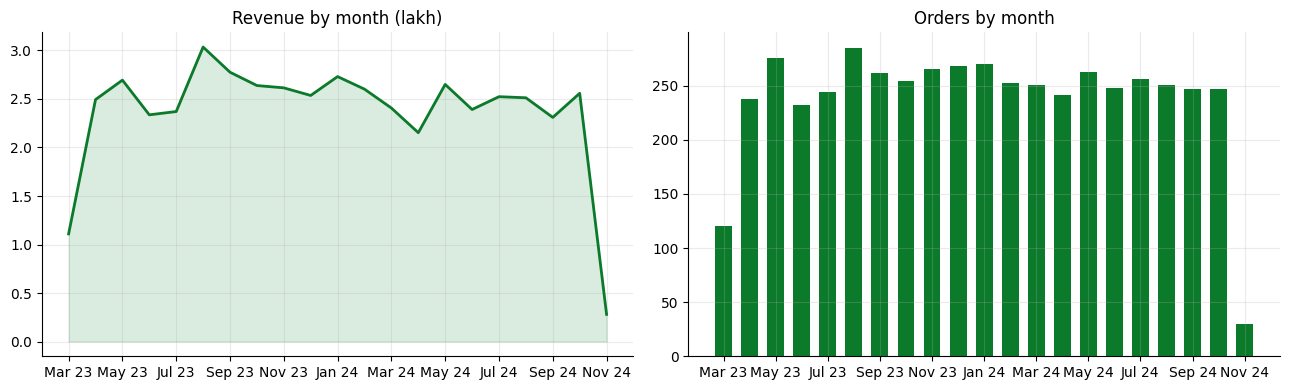

In [109]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'
m = q("SELECT order_month, SUM(revenue) AS revenue, COUNT(DISTINCT order_id) AS orders FROM f_sales GROUP BY 1 ORDER BY 1")
labels = pd.to_datetime(m.order_month).dt.strftime('%b %y')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].fill_between(range(len(m)), m.revenue/1e5, color=GREEN, alpha=.15)
ax[0].plot(range(len(m)), m.revenue/1e5, color=GREEN, lw=2)
ax[0].set_title('Revenue by month (lakh)'); ax[0].set_xticks(range(0, len(m), 2)); ax[0].set_xticklabels(labels[::2], rotation=0)
ax[1].bar(range(len(m)), m.orders, color=GREEN, width=.65)
ax[1].set_title('Orders by month'); ax[1].set_xticks(range(0, len(m), 2)); ax[1].set_xticklabels(labels[::2])
plt.tight_layout(); plt.show()

### 16.2 Revenue concentration curve

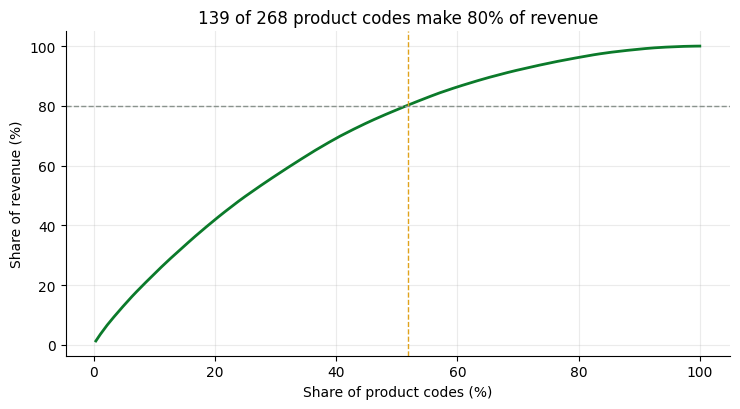

In [110]:
p = q("SELECT product_id, SUM(revenue) AS revenue FROM f_sales GROUP BY 1").sort_values('revenue', ascending=False)
cum = 100 * p.revenue.cumsum() / p.revenue.sum()
x = 100 * np.arange(1, len(p)+1) / len(p)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x, cum, color=GREEN, lw=2)
ax.axhline(80, color=GREY, ls='--', lw=1); ax.axvline(float(x[(cum >= 80).idxmax() if hasattr(cum,'idxmax') else 0]) if False else x[np.argmax(cum.values >= 80)], color=GOLD, ls='--', lw=1)
ax.set_xlabel('Share of product codes (%)'); ax.set_ylabel('Share of revenue (%)')
ax.set_title(f'{np.argmax(cum.values >= 80)+1} of {len(p)} product codes make 80% of revenue')
plt.tight_layout(); plt.show()

### 16.3 Minutes against the promised time

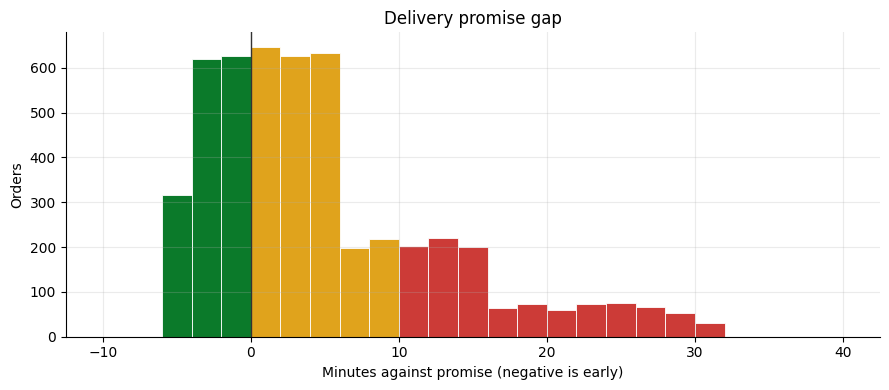

In [111]:
d = q('SELECT delay_min FROM f_sales')
clip = d.delay_min.clip(-10, 40)
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(-10, 42, 2)
counts, edges, patches = ax.hist(clip, bins=bins, color=GREEN, edgecolor='white', linewidth=.6)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(GREEN if left < 0 else GOLD if left < 10 else RED)
ax.axvline(0, color='#333', lw=1)
ax.set_xlabel('Minutes against promise (negative is early)'); ax.set_ylabel('Orders')
ax.set_title('Delivery promise gap'); plt.tight_layout(); plt.show()

### 16.4 Stock cover against shelf life

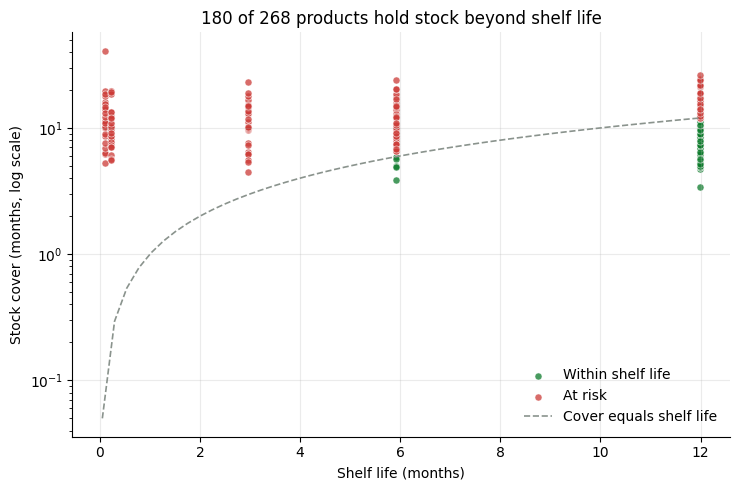

In [112]:
s = stock.dropna(subset=['stock_cover_months'])
fig, ax = plt.subplots(figsize=(7.5, 5))
risky = s[s.wastage_risk == 'At risk']; safe = s[s.wastage_risk != 'At risk']
ax.scatter(safe.shelf_life_months, safe.stock_cover_months, s=26, color=GREEN, alpha=.75, label='Within shelf life', edgecolor='white', lw=.5)
ax.scatter(risky.shelf_life_months, risky.stock_cover_months, s=26, color=RED, alpha=.75, label='At risk', edgecolor='white', lw=.5)
lim = np.linspace(0.05, s.shelf_life_months.max(), 50)
ax.plot(lim, lim, color=GREY, ls='--', lw=1.2, label='Cover equals shelf life')
ax.set_yscale('log'); ax.set_xlabel('Shelf life (months)'); ax.set_ylabel('Stock cover (months, log scale)')
ax.set_title(f'{len(risky)} of {len(s)} products hold stock beyond shelf life'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 16.5 Demand by day and hour

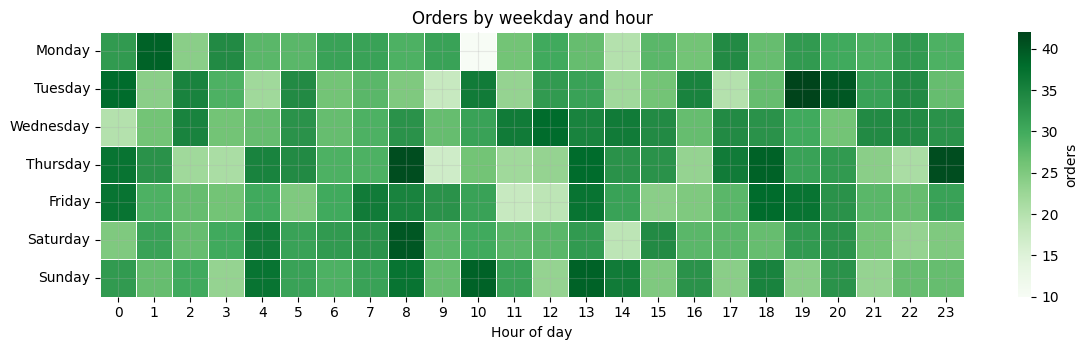

In [113]:
fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(heat_pivot, cmap='Greens', linewidths=.6, linecolor='white', cbar_kws={'label':'orders'}, ax=ax)
ax.set_title('Orders by weekday and hour'); ax.set_xlabel('Hour of day'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 16.6 Cohort retention

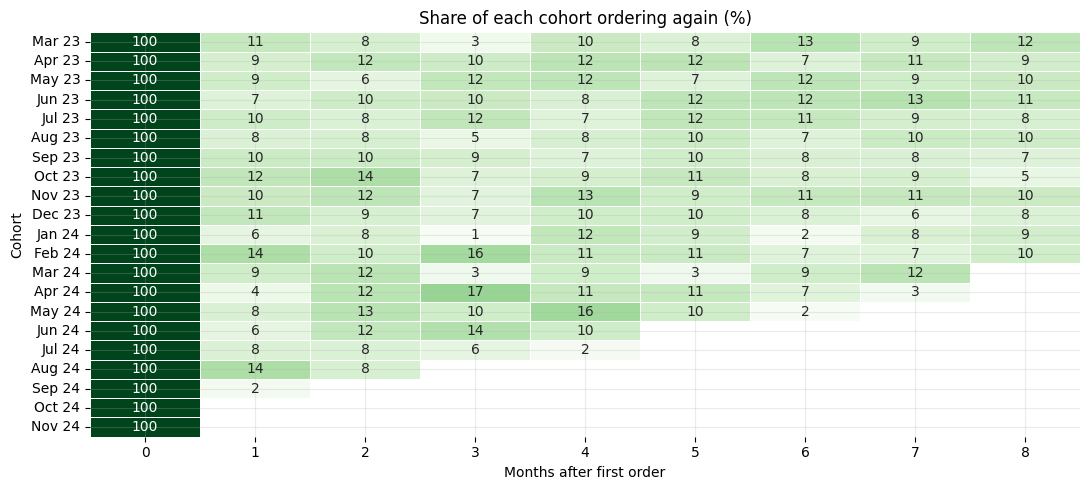

In [114]:
cohort = q('''
WITH first_order AS (SELECT customer_id, date_trunc('month', MIN(order_date)) AS cohort FROM f_sales GROUP BY 1),
activity AS (SELECT f.cohort, date_diff('month', f.cohort, s.order_month) AS month_index, s.customer_id
             FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id)
SELECT cohort, month_index, COUNT(DISTINCT customer_id) AS customers FROM activity GROUP BY 1, 2 ''')
cp = cohort.pivot(index='cohort', columns='month_index', values='customers')
cp = cp.div(cp[0], axis=0).mul(100).round(1).iloc[:, :9]
cp.index = pd.to_datetime(cp.index).strftime('%b %y')
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cp, annot=True, fmt='.0f', cmap='Greens', vmax=40, linewidths=.6, linecolor='white', cbar=False, ax=ax)
ax.set_title('Share of each cohort ordering again (%)'); ax.set_xlabel('Months after first order'); ax.set_ylabel('Cohort')
plt.tight_layout(); plt.show()

### 16.7 Customer groups

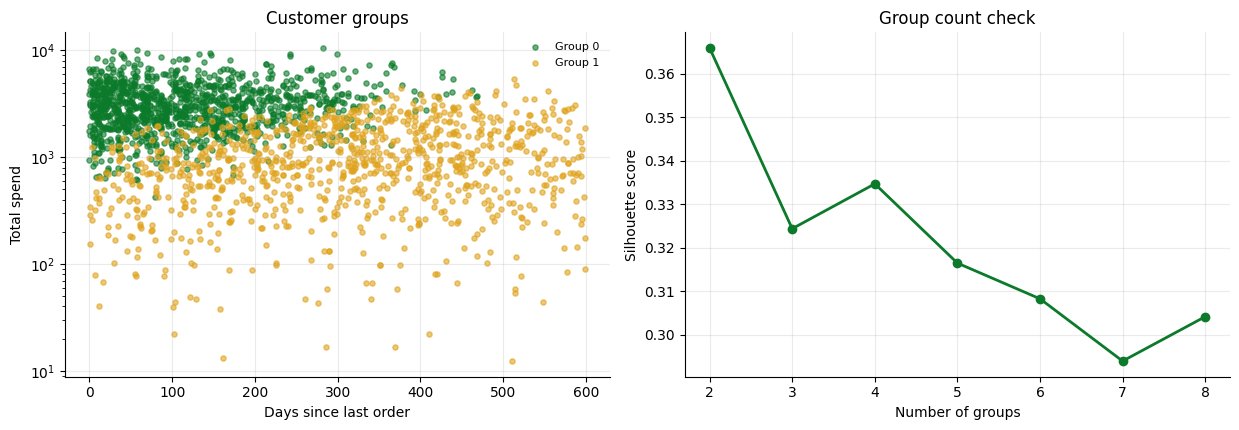

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
palette = [GREEN, GOLD, BLUE, RED, '#7A5BD0']
for c in sorted(rfm.cluster.unique()):
    g = rfm[rfm.cluster == c]
    ax[0].scatter(g.recency_days, g.monetary, s=14, alpha=.6, color=palette[c % len(palette)], label=f'Group {c}')
ax[0].set_xlabel('Days since last order'); ax[0].set_ylabel('Total spend'); ax[0].set_yscale('log')
ax[0].set_title('Customer groups'); ax[0].legend(frameon=False, fontsize=8)
sil = pd.DataFrame(scores)
ax[1].plot(sil.k, sil.silhouette, marker='o', color=GREEN, lw=2)
ax[1].set_xlabel('Number of groups'); ax[1].set_ylabel('Silhouette score'); ax[1].set_title('Group count check')
plt.tight_layout(); plt.show()

### 16.8 Category revenue against margin

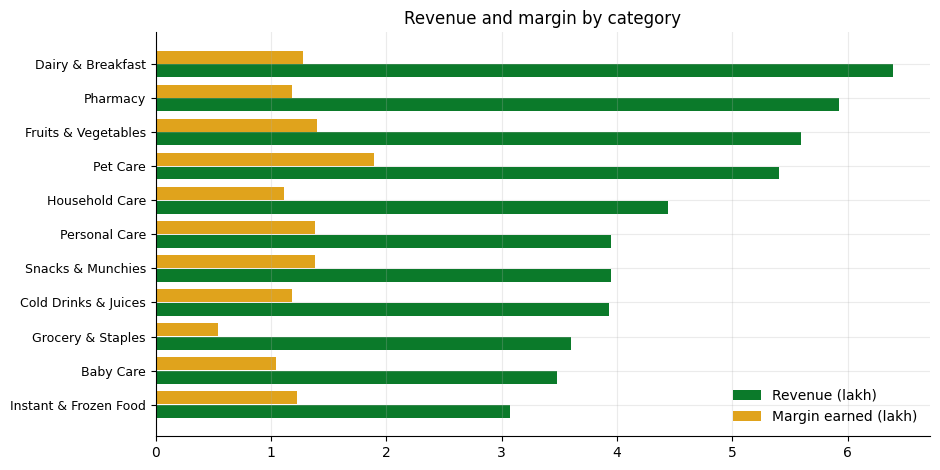

In [116]:
c = q('SELECT category, SUM(revenue) AS revenue, SUM(margin_value) AS margin FROM f_sales GROUP BY 1').sort_values('revenue')
fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(c))
ax.barh(y - .2, c.revenue/1e5, height=.38, color=GREEN, label='Revenue (lakh)')
ax.barh(y + .2, c.margin/1e5, height=.38, color=GOLD, label='Margin earned (lakh)')
ax.set_yticks(y); ax.set_yticklabels(c.category, fontsize=9); ax.legend(frameon=False)
ax.set_title('Revenue and margin by category'); plt.tight_layout(); plt.show()

### 16.9 On-time rate by state

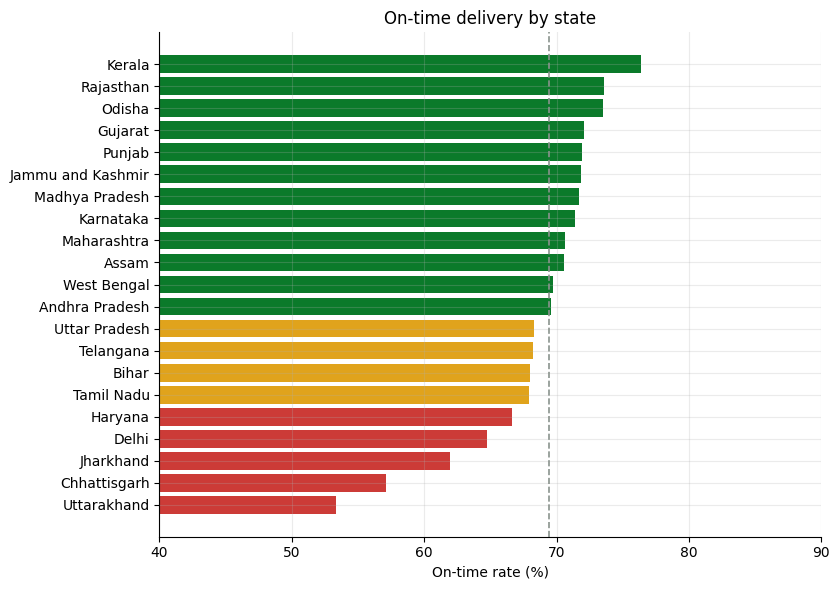

In [117]:
st = q('''
SELECT state, COUNT(*) AS orders,
       100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) AS on_time
FROM f_sales GROUP BY 1 HAVING COUNT(*) >= 30 ORDER BY on_time ''')
overall = q('SELECT 100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*) AS ot FROM f_sales').ot[0]
fig, ax = plt.subplots(figsize=(8.5, 6))
colors = [RED if v < overall - 2 else GOLD if v < overall else GREEN for v in st.on_time]
ax.barh(st.state, st.on_time, color=colors)
ax.axvline(overall, color=GREY, ls='--', lw=1.2)
ax.set_xlim(40, 90); ax.set_xlabel('On-time rate (%)'); ax.set_title('On-time delivery by state')
plt.tight_layout(); plt.show()

### 16.10 Forecast against actual units

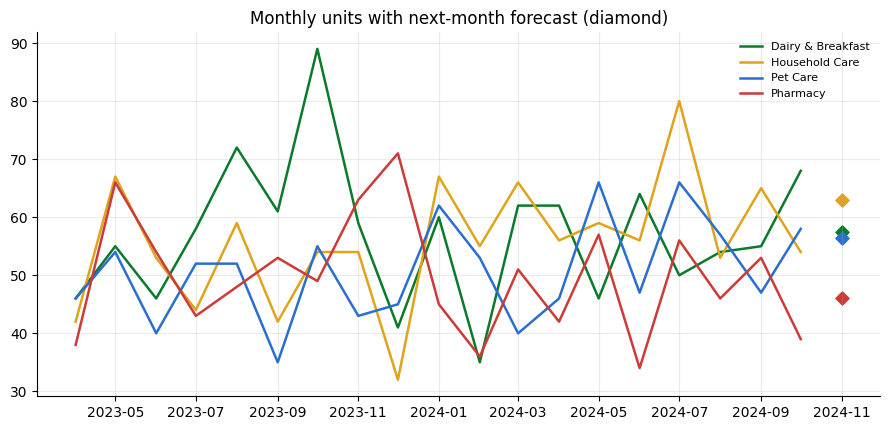

In [118]:
fig, ax = plt.subplots(figsize=(9, 4.4))
top_cats = fc.sort_values('avg_monthly_units', ascending=False).category.head(4)
for i, cat in enumerate(top_cats):
    g = series[series.category == cat]
    ax.plot(pd.to_datetime(g.order_month), g.units, lw=1.8, color=[GREEN, GOLD, BLUE, RED][i], label=cat)
    nxt = fc.set_index('category').loc[cat, 'next_month_forecast']
    ax.scatter([pd.to_datetime(g.order_month).max() + pd.DateOffset(months=1)], [nxt],
               color=[GREEN, GOLD, BLUE, RED][i], marker='D', s=45)
ax.set_title('Monthly units with next-month forecast (diamond)'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 17. Output files

### 17.1 Summary of findings

In [119]:
findings = pd.DataFrame([
 ['Sales', 'Revenue', f"{q('SELECT SUM(revenue) AS r FROM f_sales').r[0]:,.0f} from 5,000 orders"],
 ['Sales', 'Product codes for 80% of revenue', f"{np.argmax((100*p.revenue.cumsum()/p.revenue.sum()).values >= 80)+1} of {len(p)}"],
 ['Customers', 'Repeat revenue share', f"{q('''WITH c AS (SELECT customer_id, COUNT(DISTINCT order_id) o, SUM(revenue) s FROM f_sales GROUP BY 1) SELECT 100.0*SUM(s) FILTER (WHERE o>=2)/SUM(s) AS v FROM c''').v[0]:.1f}%"],
 ['Customers', 'Median gap to second order', f"{q('''WITH s AS (SELECT customer_id, order_date, ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) rn, LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) prev FROM (SELECT DISTINCT customer_id, order_date FROM f_sales)) SELECT median(date_diff('day', prev, order_date)) AS v FROM s WHERE rn = 2''').v[0]:.0f} days"],
 ['Funnel', 'Registered customers who never ordered', f"{q('SELECT COUNT(*) AS v FROM customers_src c LEFT JOIN orders o ON o.customer_id=c.customer_id WHERE o.order_id IS NULL').v[0]}"],
 ['Delivery', 'Orders after promised time', f"{q('SELECT 100.0*COUNT(*) FILTER (WHERE delay_min>0)/COUNT(*) AS v FROM f_sales').v[0]:.1f}%"],
 ['Delivery', 'Rating difference across statuses', f"ANOVA p-value {anova.pvalue:.3f}"],
 ['Inventory', 'Products at wastage risk', f"{int((stock.wastage_risk=='At risk').sum())} of {len(stock)}"],
 ['Inventory', 'Stock value released by new levels', f"{plan.released_value.sum():,.0f}"],
 ['Margin', 'Category rank shift', 'Dairy & Breakfast 1st by revenue, 5th by margin'],
 ['Time', 'Demand per hour across slots', f"{q('''WITH s AS (SELECT order_time_slot, COUNT(*) o, COUNT(DISTINCT order_hour) h FROM f_sales GROUP BY 1) SELECT MIN(o/h) AS a, MAX(o/h) AS b FROM s''').iloc[0].tolist()}"],
 ['Region', 'Top zone by revenue', q('SELECT zone FROM f_sales GROUP BY 1 ORDER BY SUM(revenue) DESC LIMIT 1').zone[0]],
 ['Forecast', 'Average MAPE across categories', f"{fc.mape_pct.mean():.1f}%"],
], columns=['area','measure','value'])
findings

,area,measure,value
0,Sales,Revenue,"4,972,415 from 5,000 orders"
1,Sales,Product codes for 80% of revenue,139 of 268
2,Customers,Repeat revenue share,86.7%
3,Customers,Median gap to second order,135 days
4,Funnel,Registered customers who never ordered,328
5,Delivery,Orders after promised time,62.0%
6,Delivery,Rating difference across statuses,ANOVA p-value 0.342
7,Inventory,Products at wastage risk,180 of 268
8,Inventory,Stock value released by new levels,"1,240,232"
9,Margin,Category rank shift,"Dairy & Breakfast 1st by revenue, 5th by margin"


### 17.2 Export analysis outputs

In [120]:
import os
os.makedirs('output', exist_ok=True)
with pd.ExcelWriter('output/Blinkit_Analysis_Outputs.xlsx', engine='openpyxl') as xl:
    findings.to_excel(xl, sheet_name='Key_Findings', index=False)
    q('''SELECT strftime(order_month,'%Y-%m') AS month, COUNT(DISTINCT order_id) AS orders,
         round(SUM(revenue),2) AS revenue, round(SUM(margin_value),2) AS margin FROM f_sales GROUP BY 1 ORDER BY 1''').to_excel(xl, sheet_name='Monthly_Sales', index=False)
    q('''SELECT category, COUNT(DISTINCT order_id) AS orders, round(SUM(revenue),2) AS revenue,
         round(SUM(margin_value),2) AS margin FROM f_sales GROUP BY 1 ORDER BY revenue DESC''').to_excel(xl, sheet_name='Category_Performance', index=False)
    states.to_excel(xl, sheet_name='State_Performance', index=False)
    scored.sort_values('priority_score', ascending=False).to_excel(xl, sheet_name='State_Priority_Score', index=False)
    plan.reset_index()[['product_id','product_name','category','shelf_life_days','price','min_stock_level',
        'avg_monthly_demand','safety_stock','reorder_point','rec_min_stock','cut_units','released_value','wastage_risk']].to_excel(xl, sheet_name='Stock_Plan', index=False)
    abc_xyz.reset_index().to_excel(xl, sheet_name='ABC_XYZ', index=False)
    rfm.to_excel(xl, sheet_name='RFM_Segments', index=False)
    profile.reset_index().to_excel(xl, sheet_name='Segment_Profile', index=False)
    fc.to_excel(xl, sheet_name='Category_Forecast', index=False)
    cand.to_excel(xl, sheet_name='SKU_Recommendations', index=False)
    km_df.to_excel(xl, sheet_name='Repeat_Curve', index=False)
    heat_pivot.reset_index().to_excel(xl, sheet_name='Hour_Day_Demand', index=False)
print(os.path.getsize('output/Blinkit_Analysis_Outputs.xlsx'), 'bytes written')
pd.DataFrame({'sheet': ['Key_Findings','Monthly_Sales','Category_Performance','State_Performance','State_Priority_Score',
                        'Stock_Plan','ABC_XYZ','RFM_Segments','Segment_Profile','Category_Forecast',
                        'SKU_Recommendations','Repeat_Curve','Hour_Day_Demand']})

178305 bytes written


,sheet
0,Key_Findings
1,Monthly_Sales
2,Category_Performance
3,State_Performance
4,State_Priority_Score
5,Stock_Plan
6,ABC_XYZ
7,RFM_Segments
8,Segment_Profile
9,Category_Forecast


### 17.3 Close the database

In [121]:
con.execute('CHECKPOINT')
tables = con.execute('SELECT table_name, estimated_size AS rows FROM duckdb_tables() ORDER BY table_name').df()
con.close()
tables

,table_name,rows
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268
